<a href="https://colab.research.google.com/github/Carolaynebarret/DataConnect/blob/main/DataConnect_Squad7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DataConnect Solutions
## Da base suja a base limpa

**Squad 7** &nbsp;·&nbsp; Carolayne, Regina, Maxxi, Ingrid
&nbsp;·&nbsp; Residencia de Dados com IA &nbsp;

---


### Como este notebook esta organizado

| Secao | O que tem nela |
|---|---|
| 1 | Como trabalhamos: o ciclo que seguimos e onde validamos |
| 2 | A camada bruta, que fica intacta e serve de testemunha |
| 3 | As ferramentas de tratamento que escrevemos |
| 4 | O diagnostico: o retrato da base antes de mexer em nada |
| 5 | As oito decisoes que tomamos, com o motivo de cada uma |
| 6 | A limpeza, tabela por tabela, com antes e depois |
| 7 | O que so aparece cruzando as tabelas |
| 8 | A prova real |
| 9 | O impacto das nossas decisoes nos numeros |
| 10 | O log, o registro de uso de IA e a exportacao |

---
# 1. Como trabalhamos

### O ciclo

O protocolo da casa define quatro etapas para todo trabalho com IA, e a gente
seguiu as quatro em cada tabela:

**Especificar.** Antes de pedir qualquer coisa, escrevemos o contexto, o esquema
real das colunas, o que precisava acontecer e como saberiamos que deu certo. Os
pedidos que fizemos estao registrados na secao 10, com o texto que usamos.

**Gerar.** Pedimos e lemos o que voltou. Quando a resposta nao servia, dissemos o
que veio errado em vez de recomecar do zero. Em duas etapas pedimos alternativas
com pros e contras, porque a decisao era de metodo e queriamos escolher nos.

**Validar.** Esta e a etapa que a gente levou mais a serio, porque codigo que roda
nao e codigo correto. Cada saida passou por pelo menos uma verificacao
independente. Onde deu, refizemos a conta na mao em tres casos.

**Registrar.** O log da secao 10 tem o que mudamos, quantas linhas cada mudanca
afetou e o que a escolha distorce. O registro de uso de IA tem o que pedimos, como
conferimos e o que corrigimos.

### Onde validamos

Fizemos a validacao em dois lugares, de proposito.

Dentro do Colab, a prova real da secao 8 confere os totais e **para o notebook**
se algum nao bater. Fora do Colab, refizemos as mesmas contas em SQL, no DB
Browser for SQLite, a partir dos CSV exportados. O arquivo `validacao.sql` esta
junto da entrega.

Rodar a mesma conta na mesma ferramenta que produziu o numero nao prova nada: se o
codigo estiver errado, os dois lados erram junto. Refazer em SQL, em outra
ferramenta, com outra sintaxe, e o que a gente entendeu por verificacao
independente.



---
# 2. A camada bruta

Comecamos pelo passo 1 dos dez: **nao mexer no original.**

Os cinco arquivos entram aqui como texto puro e ficam intactos. Toda a limpeza
acontece em copias. Se a gente errar, refaz a copia; e quando um numero da base
limpa parecer estranho, a pergunta vai ser o que o arquivo dizia ali, e a gente
vai ter onde olhar.

Usamos `dtype=str` na leitura por causa disso. Sem essa instrucao o pandas
adivinha o tipo de cada coluna e ja decide por nos o que e numero e o que e data.
Se deixarmos ele decidir, depois nao da para saber se o erro veio do arquivo ou da
nossa leitura.

In [1]:
# As bibliotecas e o visual da casa.
import re
import os
import unicodedata
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Paleta da DataConnect. Usamos ela nos poucos graficos deste notebook para nao
# ter que reaprender as cores na hora de montar o painel.
MARINHO = '#14213D'   # a serie principal
CORAL   = '#E4572E'   # um so destaque por grafico: o dado da mensagem
CINZA   = '#C5CCD6'   # contexto
TEAL    = '#2A9D8F'   # segunda mensagem positiva
AMBAR   = '#E9A93A'   # atencao ou hipotese

plt.rcParams.update({
    'figure.dpi': 110, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': CINZA, 'axes.labelcolor': MARINHO, 'text.color': MARINHO,
    'xtick.color': MARINHO, 'ytick.color': MARINHO,
    'axes.grid': True, 'grid.color': CINZA, 'grid.alpha': .35,
    'axes.axisbelow': True,
})
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

print('Rodado em', datetime.now().strftime('%d/%m/%Y as %H:%M'))

Rodado em 28/08/2026 as 17:15


In [2]:
# Onde estao os arquivos. E a unica celula que precisa ser ajustada para rodar
# em outra maquina.
USAR_DRIVE = True
PASTA = '/content/drive/MyDrive/dados-dataconnect'

if USAR_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
else:
    PASTA = '.'

ARQUIVOS = {
    'projetos':     f'{PASTA}/dc_projetos.csv',
    'apontamentos': f'{PASTA}/dc_apontamentos.csv',
    'clientes':     f'{PASTA}/dc_clientes.csv',
    'analistas':    f'{PASTA}/dc_analistas.csv',
    'satisfacao':   f'{PASTA}/dc_satisfacao.csv',
}

# A chave primaria de cada tabela, segundo o dicionario de dados do brief.
CHAVES = {'projetos': 'projeto_id', 'apontamentos': 'apontamento_id',
          'clientes': 'cliente_id', 'analistas': 'analista_id',
          'satisfacao': 'pesquisa_id'}

COLUNAS_DATA = {'projetos': ['data_inicio', 'data_fim_prevista', 'data_fim_real'],
                'apontamentos': ['data'], 'clientes': ['data_cadastro'],
                'analistas': ['data_admissao'], 'satisfacao': ['data_pesquisa']}

COLUNAS_NUMERO = {'projetos': ['valor_contrato', 'horas_vendidas'],
                  'apontamentos': ['horas'], 'analistas': ['custo_hora'],
                  'satisfacao': ['nota_nps'], 'clientes': []}

# As colunas de categoria que a gente vai acompanhar no antes e depois.
COLUNAS_FOCO = {'analistas': ['squad', 'senioridade'],
                'clientes': ['setor', 'porte', 'uf'],
                'projetos': ['tipo_servico', 'status', 'squad'],
                'apontamentos': ['atividade'], 'satisfacao': []}

Mounted at /content/drive


In [3]:
# A leitura crua. keep_default_na=False evita que o pandas transforme textos como
# 'NA' ou 'null' em vazio por conta propria: so a celula realmente vazia vira nulo.
bruto = {}
for nome, caminho in ARQUIVOS.items():
    bruto[nome] = pd.read_csv(caminho, dtype=str, keep_default_na=False,
                              na_values=[''], encoding='utf-8')

print('O que entrou:')
for nome, df in bruto.items():
    tudo_texto = (df.dtypes == object).all()
    print(f'  {nome:<14} {len(df):>6} linhas  {df.shape[1]:>2} colunas  '
          f'tudo como texto: {"sim" if tudo_texto else "NAO"}')

print()
print('Estas contagens sao o nosso ponto de partida. Elas vao aparecer de novo na')
print('prova real, no fim, para mostrar quantas linhas sairam e por que.')

O que entrou:
  projetos          141 linhas  11 colunas  tudo como texto: sim
  apontamentos     9879 linhas   6 colunas  tudo como texto: sim
  clientes           62 linhas   7 colunas  tudo como texto: sim
  analistas          24 linhas   6 colunas  tudo como texto: sim
  satisfacao        103 linhas   5 colunas  tudo como texto: sim

Estas contagens sao o nosso ponto de partida. Elas vao aparecer de novo na
prova real, no fim, para mostrar quantas linhas sairam e por que.


In [4]:
# Uma olhada nas primeiras linhas de cada arquivo, do jeito que chegou.
# E aqui que a gente ve pela primeira vez a bagunca de que a aula falou.
for nome in ['projetos', 'apontamentos', 'clientes', 'analistas', 'satisfacao']:
    print(f'--- {nome} ---')
    display(bruto[nome].head(3))

--- projetos ---


,projeto_id,cliente_id,nome_projeto,tipo_servico,squad,status,data_inicio,data_fim_prevista,data_fim_real,horas_vendidas,valor_contrato
0,PRJ0001,CLI013,Dashboard BI - Windsor,Dashboard B.I.,Delta,CONCLUÍDO,2024-03-19,2024-05-06,08/05/2024,288,NaN
1,PRJ0002,CLI022,Diagnóstico de Dados - Umbu,Diagnóstico de Dados,Alpha,Cancelado,2024-10-01,2024-10-28,NaN,89,24044.51
2,PRJ0003,CLI051,Pipeline de Dados - Cristal,Pipeline de Dados,Charlie,Concluído,2025-06-16,20/10/2025,10/15/2025,423,91525.58


--- apontamentos ---


,apontamento_id,projeto_id,analista_id,data,horas,atividade
0,APT002473,PRJ0032,ANL006,2026-03-23,6,Reunião com cliente
1,APT004798,PRJ0064,ANL008,2026-05-08,6.5,Apresentação
2,APT005566,PRJ0079,ANL012,2025-06-02,6,Coleta


--- clientes ---


,cliente_id,cliente,setor,porte,cidade,uf,data_cadastro
0,CLI001,Umbu S.A.,NaN,Pequeno,Rio de Janeiro,Rio de Janeiro,2021-10-13
1,CLI002,Xingu S.A.,Indústria,Médio,Florianópolis,SC,2021-03-07
2,CLI003,Aurora S.A.,Saúde,Médio,Curitiba,PR,2021-02-24


--- analistas ---


,analista_id,analista,squad,senioridade,custo_hora,data_admissao
0,ANL001,Ana Barbosa,ALPHA,Senior,"150,00",2021-12-07
1,ANL002,Bruno Ipiranga,Bravo,Pleno,95.00,2021-08-30
2,ANL003,Carla Esteves,Charlie,Junior,55.00,2024-12-26


--- satisfacao ---


,pesquisa_id,projeto_id,data_pesquisa,nota_nps,comentario
0,PSQ0001,PRJ0001,2024-05-27,NaN,"Resultado ok, prazo apertado."
1,PSQ0002,PRJ0003,2025-10-20,10,Documentação impecável.
2,PSQ0003,PRJ0004,2024-05-08,9,Documentação impecável.


---
# 3. As ferramentas que escrevemos

Escrevemos as funcoes uma vez e usamos nas cinco tabelas. Isso poupou tempo, mas o
motivo principal foi outro: se a regra de conversao de data e uma so, ela e uma so
em todo lugar. Nos dois rascunhos anteriores a gente tinha tres regras diferentes
para a mesma coluna, em celulas diferentes, e o resultado dependia de qual tinha
rodado por ultimo.



### 3.1 Texto

`normalizar_texto` apara o espaco das pontas e junta espaco repetido do meio.

Decidimos **nao** usar `.str.title()`, que era o que a gente vinha fazendo. Ele
quebra nome de pessoa ("Ana de Souza" vira "Ana De Souza") e nao resolve variantes
com ponto, que era justamente o caso que a gente queria resolver.

`chave_categoria` monta a chave de comparacao: minuscula, sem acento e sem
pontuacao. E ela que faz `Dashboard B.I.` e `DASHBOARD BI` caírem no mesmo lugar.

A aula avisa que em SQLite a funcao de minuscula ignora acento, e que por isso a
base parece limpa e continua com 13 setores numa empresa que atende 10. Em Python
o problema so nao acontece se a decomposicao do acento for feita antes, que e o
que o `normalize('NFD')` faz aqui. Nao e automatico: se a gente so tivesse chamado
`.lower()`, cairiamos na mesma armadilha.

In [5]:
def normalizar_texto(valor):
    # Apara as pontas e junta espaco repetido. Nao mexe na caixa das letras:
    # decidir se 'ALPHA' e 'Alpha' sao a mesma coisa e trabalho do passo 5.
    if pd.isna(valor):
        return pd.NA
    texto = unicodedata.normalize('NFKC', str(valor)).replace('\xa0', ' ')
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto if texto else pd.NA


def chave_categoria(valor):
    # A chave de comparacao. Tira acento, pontuacao e caixa, e o que sobra e so a
    # letra. Duas grafias que caem na mesma chave sao a mesma coisa para a maquina.
    texto = normalizar_texto(valor)
    if pd.isna(texto):
        return pd.NA
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    return re.sub(r'[^a-z0-9]+', '', texto.lower())


# Antes de usar a funcao em 10 mil linhas, conferimos nos casos que a aula cita.
print('Como a chave se comporta nos casos da aula:')
for exemplo in ['  Dashboard BI ', 'DASHBOARD BI', 'Dashboard B.I.', 'dashboard  bi',
                'EDUCAÇÃO', 'Educação', 'EducaÇÃo']:
    print(f'  {exemplo!r:>20}  ->  {chave_categoria(exemplo)}')
print()
print('Se as tres grafias de Dashboard e as tres de Educacao caem cada uma na sua')
print('chave unica, a armadilha do acento nao vai nos pegar.')

Como a chave se comporta nos casos da aula:
     '  Dashboard BI '  ->  dashboardbi
        'DASHBOARD BI'  ->  dashboardbi
      'Dashboard B.I.'  ->  dashboardbi
       'dashboard  bi'  ->  dashboardbi
            'EDUCAÇÃO'  ->  educacao
            'Educação'  ->  educacao
            'EducaÇÃo'  ->  educacao

Se as tres grafias de Dashboard e as tres de Educacao caem cada uma na sua
chave unica, a armadilha do acento nao vai nos pegar.


### 3.2 Numeros

A aula mostra o erro de `61.970,49` virar `61,97`: o ponto e separador de milhar,
o programa le "61 ponto 970 virgula 49", desiste no meio e guarda 61,97. Sessenta
e um mil reais viram sessenta e um reais e nada avisa.

A correcao que a gente tinha aplicado era tirar o ponto e trocar a virgula, na
coluna inteira. So que essa regra assume que **todo** valor da coluna esta no
formato brasileiro. Se algum estiver no formato ISO, com o ponto como separador
decimal, tirar o ponto multiplica o valor por cem.

Foi o que aconteceu no nosso relatorio anterior: apareceram contratos de doze
milhoes numa empresa cujo contrato medio e de sessenta mil, e a gente chegou a
escrever que isso "chamava atencao" e merecia checagem com o negocio. Nao merecia:
era a nossa conversao.

Por isso a funcao abaixo nao aplica uma regra unica. Ela **reconhece o formato de
cada valor** e devolve, junto com o numero, qual formato identificou, para o
diagnostico poder mostrar quantos valores de cada tipo existem na coluna. Se os
dois formatos convivem, a gente quer ver isso escrito.

In [6]:
def to_decimal(valor, permitir_milhar=True):
    # Devolve (numero, formato). Olha o desenho de cada valor antes de converter.
    # A ordem dos testes importa: o padrao mais especifico vem primeiro.
    if pd.isna(valor):
        return np.nan, 'vazio'
    texto = normalizar_texto(valor)
    if pd.isna(texto):
        return np.nan, 'vazio'

    texto = re.sub(r'(?i)^r\$\s*', '', texto).strip()
    negativo = texto.startswith('-')
    texto = texto.lstrip('+-').strip()

    if permitir_milhar and re.fullmatch(r'\d{1,3}(\.\d{3})+,\d{1,2}', texto):
        # 61.970,49 -> tira o ponto de milhar ANTES de trocar a virgula.
        limpo_, fmt = texto.replace('.', '').replace(',', '.'), 'BR milhar+decimal'
    elif re.fullmatch(r'\d+,\d{1,2}', texto):
        limpo_, fmt = texto.replace(',', '.'), 'BR decimal'
    elif permitir_milhar and re.fullmatch(r'\d{1,3}(\.\d{3})+', texto):
        limpo_, fmt = texto.replace('.', ''), 'BR milhar'
    elif permitir_milhar and re.fullmatch(r'\d{1,3}(,\d{3})+\.\d{1,2}', texto):
        limpo_, fmt = texto.replace(',', ''), 'US milhar+decimal'
    elif re.fullmatch(r'\d+\.\d+', texto):
        # 124698.57 -> aqui o ponto e decimal. Tirar ele seria o erro de 100x.
        limpo_, fmt = texto, 'ISO decimal'
    elif re.fullmatch(r'\d+', texto):
        limpo_, fmt = texto, 'inteiro'
    else:
        return np.nan, 'nao reconhecido'

    numero = float(limpo_)
    return (-numero if negativo else numero), fmt


def coluna_decimal(serie, permitir_milhar=True):
    pares = serie.map(lambda v: to_decimal(v, permitir_milhar))
    return (pares.map(lambda p: p[0]).astype('float64'),
            pares.map(lambda p: p[1]))


print('Conferindo a funcao nos casos que nos preocupavam:')
print(f"{'entrada':>16} | {'saida':>16} | formato")
for c in ['R$ 61.970,49', '61.970,49', '202.435,52', '124698.57', '99999999',
          '6,5', '-4']:
    n, f = to_decimal(c)
    print(f'{c!r:>16} | {n:>16,.2f} | {f}')

Conferindo a funcao nos casos que nos preocupavam:
         entrada |            saida | formato
  'R$ 61.970,49' |        61,970.49 | BR milhar+decimal
     '61.970,49' |        61,970.49 | BR milhar+decimal
    '202.435,52' |       202,435.52 | BR milhar+decimal
     '124698.57' |       124,698.57 | ISO decimal
      '99999999' |    99,999,999.00 | inteiro
           '6,5' |             6.50 | BR decimal
            '-4' |            -4.00 | inteiro


### 3.3 Datas

O passo 7 dos dez diz para onde a data vai e o que fazer com a duvida:

> Todas no mesmo formato: **ano, mes, dia**. A de barra vira `2024-05-08`, a de mes
> por extenso vira `2025-11-17`. E a duvidosa sai marcada, nao escondida.

E a regra de leitura, na demonstracao da mesma aula:

> Se o numero do meio passa de 12, e mes/dia. As duvidosas ganham aviso, nao somem.

O exemplo do slide resolve o nosso caso: `08/05/2024` vira `2024-05-08` **e fica
marcada**, e `10/15/2025` vira `2025-10-15` sem marca, porque 15 nao pode ser mes.
Ou seja, o padrao e brasileiro, mas a duvida tem que ficar visivel.

Era isso que a gente nao estava fazendo. `pd.to_datetime(format='mixed',
dayfirst=True)` converte tudo e nao marca nada. A conversao dava certo em cem por
cento das linhas, sem erro nenhum, e a gente tomava isso como prova de que estava
certo. E o erro que cala de que a aula fala: o numero entra errado, a conta
funciona, o total fica com cara de total.

Nossa funcao devolve tres coisas em vez de uma: a data, o formato que reconheceu e
se ela e ambigua.

In [7]:
MESES_PT = {'jan': 1, 'fev': 2, 'mar': 3, 'abr': 4, 'mai': 5, 'jun': 6,
            'jul': 7, 'ago': 8, 'set': 9, 'out': 10, 'nov': 11, 'dez': 12,
            'janeiro': 1, 'fevereiro': 2, 'marco': 3, 'abril': 4, 'maio': 5,
            'junho': 6, 'julho': 7, 'agosto': 8, 'setembro': 9, 'outubro': 10,
            'novembro': 11, 'dezembro': 12}

_cache_data = {}   # a mesma data aparece milhares de vezes; guardamos o resultado


def _montar(ano, mes, dia):
    try:
        return pd.Timestamp(year=int(ano), month=int(mes), day=int(dia))
    except (ValueError, TypeError):
        return pd.NaT


def parse_data(valor):
    # Devolve (data, formato, ambigua). Destino sempre aaaa-mm-dd.
    if pd.isna(valor):
        return pd.NaT, 'vazio', False
    texto = normalizar_texto(valor)
    if pd.isna(texto):
        return pd.NaT, 'vazio', False
    if texto in _cache_data:
        return _cache_data[texto]

    base = texto.split(' ')[0].split('T')[0]
    resultado = (pd.NaT, 'nao reconhecido', False)

    # a) ja vem em aaaa-mm-dd. Nao ha duvida possivel.
    m = re.fullmatch(r'(\d{4})-(\d{1,2})-(\d{1,2})', base)
    if m:
        resultado = (_montar(*m.groups()), 'ISO aaaa-mm-dd', False)

    # b) mes por extenso: 17-nov-2025. Tambem nao ha duvida.
    if pd.isna(resultado[0]):
        m = re.fullmatch(r'(\d{1,2})[-/ ]([a-zA-Zçãéíêôú]{3,})[-/ ](\d{4})', base)
        if m and chave_categoria(m.group(2)) in MESES_PT:
            resultado = (_montar(m.group(3), MESES_PT[chave_categoria(m.group(2))],
                                 m.group(1)), 'mes por extenso', False)

    # c) numerica com barra. Aqui mora a duvida.
    if pd.isna(resultado[0]):
        m = re.fullmatch(r'(\d{1,2})[/-](\d{1,2})[/-](\d{4})', base)
        if m:
            a, b, ano = int(m.group(1)), int(m.group(2)), m.group(3)
            if b > 12 and a <= 12:
                # o segundo numero passa de 12, entao so pode ser dia: mm/dd
                resultado = (_montar(ano, a, b), 'mm/dd/aaaa (mes primeiro)', False)
            elif a > 12 and b <= 12:
                # o primeiro passa de 12, entao e dia: dd/mm
                resultado = (_montar(ano, b, a), 'dd/mm/aaaa (dia primeiro)', False)
            elif a <= 12 and b <= 12:
                # os dois cabem em 12. O dado nao diz qual e.
                # Lemos como dd/mm, que e o padrao daqui, e MARCAMOS.
                resultado = (_montar(ano, b, a), 'ambigua (lida como dd/mm)', True)

    # formato reconhecido, mas data que nao existe no calendario (31/02, por ex.)
    if pd.isna(resultado[0]) and resultado[1] not in ('vazio', 'nao reconhecido'):
        resultado = (pd.NaT, 'data impossivel', False)

    _cache_data[texto] = resultado
    return resultado


def coluna_data(serie):
    trios = serie.map(parse_data)
    return (pd.to_datetime(trios.map(lambda t: t[0])),
            trios.map(lambda t: t[1]),
            trios.map(lambda t: t[2]).astype(bool))


print('Conferindo contra os exemplos do slide:')
print(f"{'entrada':>15} | {'saida':>12} | ambigua | formato")
for c in ['2024-04-26', '08/05/2024', '10/15/2025', '17-nov-2025', '15/10/2025',
          '31/02/2024']:
    d, f, amb = parse_data(c)
    s = d.strftime('%Y-%m-%d') if pd.notna(d) else 'NaT'
    print(f'{c!r:>15} | {s:>12} | {"SIM" if amb else "nao":>7} | {f}')

Conferindo contra os exemplos do slide:
        entrada |        saida | ambigua | formato
   '2024-04-26' |   2024-04-26 |     nao | ISO aaaa-mm-dd
   '08/05/2024' |   2024-05-08 |     SIM | ambigua (lida como dd/mm)
   '10/15/2025' |   2025-10-15 |     nao | mm/dd/aaaa (mes primeiro)
  '17-nov-2025' |   2025-11-17 |     nao | mes por extenso
   '15/10/2025' |   2025-10-15 |     nao | dd/mm/aaaa (dia primeiro)
   '31/02/2024' |          NaT |     nao | data impossivel


### 3.4 Espelhar uma data, e o teste de sanidade

`espelhar` troca o dia pelo mes de uma data. A gente vai precisar disso na secao 6:
quando um projeto tem termino anterior ao inicio, uma das datas pode estar
invertida, e essa funcao produz a leitura alternativa.

Ela devolve vazio quando a troca nao forma data valida, e isso ja e um filtro
util: se o dia passa de 12, nao existe leitura alternativa, entao nao ha o que
desempatar.

`viola_ordem` e o teste de sanidade: inicio menor
ou igual ao fim previsto, e inicio menor ou igual ao fim real. Deixamos ele
rodando, antes e depois de cada mudanca nas datas.

In [8]:
def espelhar(data):
    # Troca dia por mes. Vazio quando a troca nao forma data valida.
    if pd.isna(data) or data.day > 12:
        return pd.NaT
    return _montar(data.year, data.day, data.month)


def viola_ordem(inicio, prevista, real):
    # True quando alguma data de termino e anterior ao inicio.
    if pd.isna(inicio):
        return False
    if pd.notna(prevista) and prevista < inicio:
        return True
    if pd.notna(real) and real < inicio:
        return True
    return False


print('espelhar(2024-12-06) =', espelhar(pd.Timestamp('2024-12-06')).date(),
      ' (leitura alternativa)')
print('espelhar(2024-06-25) =', espelhar(pd.Timestamp('2024-06-25')),
      ' (dia 25 nao cabe num mes: nao existe alternativa)')

espelhar(2024-12-06) = 2024-06-12  (leitura alternativa)
espelhar(2024-06-25) = NaT  (dia 25 nao cabe num mes: nao existe alternativa)


### 3.5 O log e a prova real



In [9]:
LOG = []
PROVAS = []


def registrar(tabela, problema, linhas, decisao, distorce, nivel='amarelo'):
    LOG.append({'tabela': tabela, 'problema': problema, 'linhas afetadas': linhas,
                'o que fizemos': decisao, 'o que isso distorce': distorce,
                'nivel': nivel})


def checar(descricao, obtido, esperado=None, critica=True):
    if esperado is None:
        ok, esperado_txt = bool(obtido), 'verdadeiro'
    else:
        ok = (abs(obtido - esperado) < 0.51 if isinstance(obtido, float)
              else obtido == esperado)
        esperado_txt = esperado
    PROVAS.append({'conferencia': descricao, 'obtido': obtido,
                   'esperado': esperado_txt,
                   'resultado': 'passou' if ok else 'FALHOU',
                   'critica': 'sim' if critica else 'nao'})
    print(f'  [{"ok " if ok else "FALHA"}] {descricao}: {obtido}'
          + (f'   esperado: {esperado_txt}' if esperado is not None else ''))
    return ok


print('Log e prova real prontos.')

Log e prova real prontos.


---
# 4. O diagnostico

Passo 2 dos dez: **olhe antes de limpar.** Contamos tudo antes de mexer em nada,
porque sem o retrato de partida a gente nao consegue provar depois o que mudou.

Uma correcao que fizemos em relacao ao nosso primeiro rascunho: as contagens aqui
sao de **linhas afetadas**, nao de valores distintos. A gente estava contando com
`.unique()`, e isso faz um problema que atinge mil linhas aparecer como quarenta.
O plano de limpeza pede o tamanho medido, e medido e por linha.

In [10]:
# 4.1 O retrato de cada coluna, sem julgar nada ainda.
def perfilar(df):
    linhas = []
    for coluna in df.columns:
        s = df[coluna]
        com_espaco = s.dropna().map(lambda v: str(v) != str(v).strip()).sum()
        linhas.append({
            'coluna': coluna,
            'nulos': int(s.isna().sum()),
            '% nulo': round(100 * s.isna().mean(), 1),
            'valores distintos': int(s.nunique(dropna=True)),
            'grafias (pela chave)': int(s.dropna().map(chave_categoria).nunique()),
            'com espaco sobrando': int(com_espaco),
            'exemplo': str(s.dropna().iloc[0])[:34] if s.notna().any() else '',
        })
    return pd.DataFrame(linhas)


for nome in ['projetos', 'apontamentos', 'clientes', 'analistas', 'satisfacao']:
    print(f'=== {nome} ({len(bruto[nome])} linhas) ===')
    display(perfilar(bruto[nome]))

=== projetos (141 linhas) ===


,coluna,nulos,% nulo,valores distintos,grafias (pela chave),com espaco sobrando,exemplo
0,projeto_id,0,0.00,140,140,0,PRJ0001
1,cliente_id,0,0.00,54,54,0,CLI013
2,nome_projeto,0,0.00,87,87,0,Dashboard BI - Windsor
3,tipo_servico,0,0.00,20,6,7,Dashboard B.I.
4,squad,0,0.00,6,6,0,Delta
5,status,0,0.00,5,3,0,CONCLUÍDO
6,data_inicio,0,0.00,132,132,0,2024-03-19
7,data_fim_prevista,0,0.00,131,131,0,2024-05-06
8,data_fim_real,13,9.20,117,117,0,08/05/2024
9,horas_vendidas,0,0.00,124,124,0,288


=== apontamentos (9879 linhas) ===


,coluna,nulos,% nulo,valores distintos,grafias (pela chave),com espaco sobrando,exemplo
0,apontamento_id,0,0.00,9799,9799,0,APT002473
1,projeto_id,0,0.00,140,140,0,PRJ0032
2,analista_id,0,0.00,24,24,0,ANL006
3,data,0,0.00,2037,2037,0,2026-03-23
4,horas,0,0.00,23,16,0,6
5,atividade,0,0.00,15,8,0,Reunião com cliente


=== clientes (62 linhas) ===


,coluna,nulos,% nulo,valores distintos,grafias (pela chave),com espaco sobrando,exemplo
0,cliente_id,0,0.00,60,60,0,CLI001
1,cliente,0,0.00,60,60,9,Umbu S.A.
2,setor,5,8.10,17,10,4,Indústria
3,porte,0,0.00,3,3,0,Pequeno
4,cidade,0,0.00,10,10,0,Rio de Janeiro
5,uf,0,0.00,19,14,0,Rio de Janeiro
6,data_cadastro,0,0.00,60,60,0,2021-10-13


=== analistas (24 linhas) ===


,coluna,nulos,% nulo,valores distintos,grafias (pela chave),com espaco sobrando,exemplo
0,analista_id,0,0.00,24,24,0,ANL001
1,analista,0,0.00,24,24,0,Ana Barbosa
2,squad,0,0.00,9,6,0,ALPHA
3,senioridade,0,0.00,4,4,0,Senior
4,custo_hora,0,0.00,7,4,0,"150,00"
5,data_admissao,0,0.00,24,24,0,2021-12-07


=== satisfacao (103 linhas) ===


,coluna,nulos,% nulo,valores distintos,grafias (pela chave),com espaco sobrando,exemplo
0,pesquisa_id,0,0.00,103,103,0,PSQ0001
1,projeto_id,0,0.00,103,103,0,PRJ0001
2,data_pesquisa,0,0.00,100,100,0,2024-05-27
3,nota_nps,8,7.80,8,8,0,10
4,comentario,0,0.00,10,10,0,"Resultado ok, prazo apertado."


In [11]:
# 4.2 Os formatos que convivem dentro de cada coluna critica.
# E aqui que a gente descobre se a coluna tem um formato so ou varios.
def retrato_formatos(serie, tipo):
    formatos = (serie.map(lambda v: to_decimal(v)[1]) if tipo == 'numero'
                else serie.map(lambda v: parse_data(v)[1]))
    tab = (formatos.value_counts(dropna=False)
           .rename_axis('formato').reset_index(name='linhas'))
    tab['%'] = (100 * tab['linhas'] / len(serie)).round(1)
    return tab


for tabela in ['projetos', 'apontamentos', 'clientes', 'analistas', 'satisfacao']:
    for coluna in COLUNAS_NUMERO[tabela]:
        print(f'--- {tabela}.{coluna} (numero) ---')
        display(retrato_formatos(bruto[tabela][coluna], 'numero'))
    for coluna in COLUNAS_DATA[tabela]:
        print(f'--- {tabela}.{coluna} (data) ---')
        display(retrato_formatos(bruto[tabela][coluna], 'data'))

--- projetos.valor_contrato (numero) ---


,formato,linhas,%
0,ISO decimal,101,71.60
1,BR milhar+decimal,33,23.40
2,vazio,7,5.00


--- projetos.horas_vendidas (numero) ---


,formato,linhas,%
0,inteiro,141,100.00


--- projetos.data_inicio (data) ---


...

,formato,linhas,%
0,ISO aaaa-mm-dd,15,62.50
1,dd/mm/aaaa (dia primeiro),3,12.50
2,mes por extenso,3,12.50
3,mm/dd/aaaa (mes primeiro),2,8.30
4,ambigua (lida como dd/mm),1,4.20


--- satisfacao.nota_nps (numero) ---


,formato,linhas,%
0,inteiro,95,92.20
1,vazio,8,7.80


--- satisfacao.data_pesquisa (data) ---


,formato,linhas,%
0,ISO aaaa-mm-dd,60,58.30
1,mes por extenso,14,13.60
2,ambigua (lida como dd/mm),11,10.70
3,dd/mm/aaaa (dia primeiro),9,8.70
4,mm/dd/aaaa (mes primeiro),9,8.70


In [12]:
# 4.3 O mapa da sujeira: quantas LINHAS cada problema afeta.
achados = []

def anotar(tabela, problema, linhas):
    achados.append({'tabela': tabela, 'problema': problema, 'linhas': int(linhas)})

for nome, df in bruto.items():
    chave = CHAVES[nome]
    anotar(nome, 'linha repetida inteira', df.duplicated().sum())
    anotar(nome, f'{chave} repetido', df.duplicated(subset=[chave]).sum())
    anotar(nome, 'celulas vazias', df.isna().sum().sum())
    for coluna in COLUNAS_DATA[nome]:
        f = df[coluna].map(parse_data)
        anotar(nome, f'{coluna}: data ambigua', f.map(lambda t: t[2]).sum())
        anotar(nome, f'{coluna}: nao reconhecida ou impossivel',
               f.map(lambda t: t[1] in ('nao reconhecido', 'data impossivel')).sum())
    for coluna in COLUNAS_NUMERO[nome]:
        fmt = df[coluna].map(lambda v: to_decimal(v)[1])
        anotar(nome, f'{coluna}: escrito no formato brasileiro',
               fmt.str.startswith('BR').fillna(False).sum())
        anotar(nome, f'{coluna}: nao reconhecido', (fmt == 'nao reconhecido').sum())

mapa = (pd.DataFrame(achados).query('linhas > 0')
        .sort_values('linhas', ascending=False).reset_index(drop=True))
display(mapa)

,tabela,problema,linhas
0,apontamentos,data: data ambigua,1092
1,apontamentos,horas: escrito no formato brasileiro,402
2,apontamentos,linha repetida inteira,80
3,apontamentos,apontamento_id repetido,80
4,projetos,valor_contrato: escrito no formato brasileiro,33
5,projetos,celulas vazias,20
6,projetos,data_inicio: data ambigua,19
7,projetos,data_fim_prevista: data ambigua,15
8,projetos,data_fim_real: data ambigua,14
9,satisfacao,data_pesquisa: data ambigua,11


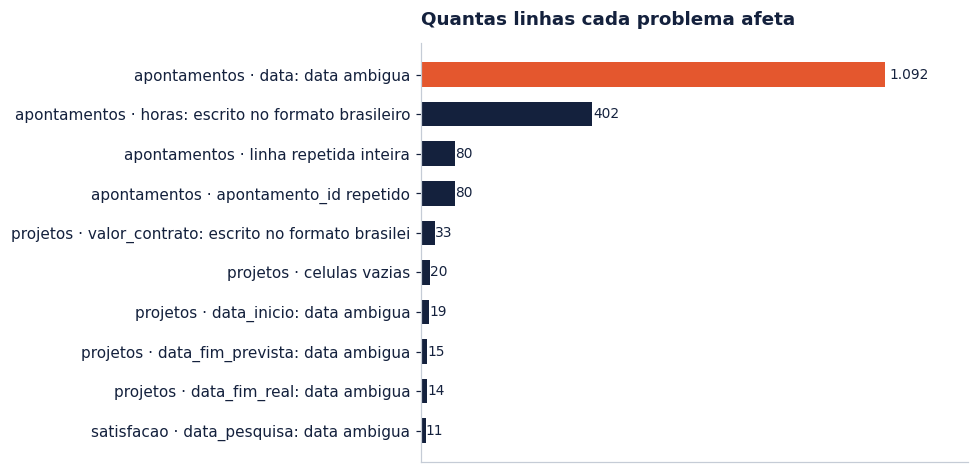

In [13]:
# 4.4 Os dez maiores, num grafico.
top = mapa.head(10).iloc[::-1]
rotulos = (top['tabela'] + ' · ' + top['problema']).str.slice(0, 54)
cores = [CORAL if v == top['linhas'].max() else MARINHO for v in top['linhas']]

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(rotulos, top['linhas'], color=cores, height=.62)
for y, v in enumerate(top['linhas']):
    ax.text(v * 1.01, y, f'{v:,.0f}'.replace(',', '.'), va='center', fontsize=9,
            color=MARINHO)
ax.set_title('Quantas linhas cada problema afeta', loc='left', fontsize=12,
             weight='bold', pad=12)
ax.set_xlim(0, top['linhas'].max() * 1.18)
ax.xaxis.set_visible(False); ax.grid(False)
plt.tight_layout(); plt.show()

### 4.5



In [14]:
# 4.5.1 Os contratos sem valor: quem sao e o que aconteceu neles?
# Precisamos saber o status e se houve trabalho, porque isso muda a leitura.
p_bruto = bruto['projetos']
valores, _ = coluna_decimal(p_bruto['valor_contrato'])
horas_ap, _ = coluna_decimal(bruto['apontamentos']['horas'], permitir_milhar=False)
horas_por_projeto = (bruto['apontamentos'].assign(h=horas_ap)
                     .groupby('projeto_id')['h'].sum())

sem_valor = p_bruto.loc[valores.isna(), ['projeto_id', 'tipo_servico', 'status',
                                         'horas_vendidas']].copy()
sem_valor['horas_apontadas'] = (sem_valor['projeto_id'].map(horas_por_projeto)
                                .fillna(0))
print(f'{len(sem_valor)} projetos sem valor de contrato:')
display(sem_valor)

7 projetos sem valor de contrato:


,projeto_id,tipo_servico,status,horas_vendidas,horas_apontadas
0,PRJ0001,Dashboard B.I.,CONCLUÍDO,288,528.00
23,PRJ0024,Pipeline de Dados,Concluído,612,541.50
46,PRJ0047,Modelo Preditivo,Concluído,406,580.50
69,PRJ0070,Modelo Preditivo,Concluído,538,918.50
92,PRJ0093,Modelo Preditivo,Concluído,374,557.00
115,PRJ0116,Diagnóstico de Dados,Concluído,133,127.00
138,PRJ0139,Modelo Preditivo,Concluído,325,385.50


In [15]:
# 4.5.2 Os apontamentos anteriores a admissao: e um analista so ou varios?
datas_ap, _, amb_ap = coluna_data(bruto['apontamentos']['data'])
datas_adm, _, _ = coluna_data(bruto['analistas']['data_admissao'])
admissao = pd.Series(datas_adm.values, index=bruto['analistas']['analista_id'])

comp = pd.DataFrame({'analista_id': bruto['apontamentos']['analista_id'],
                     'data': datas_ap, 'ambigua': amb_ap})
comp['admissao'] = comp['analista_id'].map(admissao)
comp['antes'] = comp['data'].notna() & comp['admissao'].notna() & \
                (comp['data'] < comp['admissao'])

resumo = (comp[comp['antes']].groupby('analista_id')
          .agg(apontamentos=('data', 'size'), primeiro_lancamento=('data', 'min'),
               admissao=('admissao', 'first'),
               explicados_pelo_formato=('ambigua', 'sum')).reset_index())
resumo['analista'] = resumo['analista_id'].map(
    dict(zip(bruto['analistas']['analista_id'], bruto['analistas']['analista'])))

print(f'{int(comp["antes"].sum())} apontamentos anteriores a admissao, '
      f'em {len(resumo)} analistas de {len(bruto["analistas"])}:')
display(resumo)
print('A base de projetos comeca em', bruto['projetos']['data_inicio'].map(
    lambda v: parse_data(v)[0]).min().date())

1576 apontamentos anteriores a admissao, em 8 analistas de 24:


,analista_id,apontamentos,primeiro_lancamento,admissao,explicados_pelo_formato,analista
0,ANL003,57,2024-01-03,2024-12-26,6,Carla Esteves
1,ANL004,265,2024-01-15,2025-07-28,29,Diego Freitas
2,ANL008,67,2024-01-26,2024-09-05,6,Henrique Lopes
3,ANL010,328,2024-01-15,2025-11-17,28,João Lopes
4,ANL012,126,2024-01-10,2025-02-25,16,Lucas Henriques
5,ANL018,249,2024-01-09,2025-11-29,31,Rafael Nunes
6,ANL019,243,2024-03-18,2025-12-17,31,Sofia Xavier
7,ANL020,241,2024-01-26,2025-10-30,27,Thiago Freitas


A base de projetos comeca em 2024-01-09


---
# 5. decisoes do squad


### D1 — Como ler a data ambigua

**Decidimos:** ler como dd/mm, que e o padrao daqui, e marcar toda data ambigua
com uma flag. Nos projetos, onde existe uma segunda informacao para desempatar,
usamos a coerencia `inicio <= fim`: se espelhar exatamente um campo ambiguo resolve
a violacao, aplicamos e registramos qual campo foi.

**Por que.** A regra vem do passo 7: a duvidosa sai marcada, nao escondida. O que
a gente fazia antes convertia tudo sem marcar nada, e como nao dava erro, a gente
tomava isso como prova de acerto.

 em cada projeto quebrado existe exatamente um
campo cujo dia e mes sao ambos menores que 13, e trocar so aquele campo resolve.
Dez casos com uma unica regra nao e coincidencia.


**Onde nao decidimos:** se nenhuma troca resolve, ou se mais de uma resolve, a
linha fica marcada e a data segue como dd/mm. O dado nao diz qual e a certa, e
inventar seria pior que declarar.

**O que distorce:** nas linhas marcadas que sobrarem, a data pode estar invertida.
Qualquer contagem de prazo nelas e uma aposta, e por isso elas sao rastreaveis pela
flag.

---

### D2 — O contrato fora de escala

**Decidimos:** a linha fica na base, marcada com `flag_contrato_extremo`, e sai do
calculo de margem.

**Por que.** Tirar da conta, nunca do arquivo, e a regra para valor
extremo. Um contrato dessa ordem de grandeza nao e operacao: e digitacao ou teste
de sistema. Mante-lo no calculo faz a linha de servico dele parecer a melhor da
empresa por um motivo que nao existe.

**O que distorce:** a receita analisada fica menor que a receita total da base. Os
dois numeros aparecem separados na secao 9, e o total de controle continua com ele.

---

### D3 — Os projetos sem valor de contrato

**Decidimos:** tratar como valor **ausente**, nao como receita zero. Ficam fora do
numerador e do denominador da margem, marcados com `flag_contrato_ausente`, e
entram no relatorio como achado proprio.

**Por que.** A celula 4.5.1 mostrou o que sao: todos concluidos, todos com horas
apontadas, varios com mais horas apontadas do que vendidas. Ninguem entrega
centenas de horas de graca e marca o projeto como concluido. A leitura honesta e
que o campo nao foi preenchido, nao que a receita foi zero.

Contar como zero jogaria a margem da linha de servico deles para baixo por um
motivo inventado. Imputar a media inventaria receita que nao existe. Nao contar e
a unica das tres que nao inventa nada.

**O que distorce:** a margem e calculada sobre menos projetos do que a base tem, e
isso precisa estar escrito na legenda do painel. E se esses projetos realmente nao
foram faturados, a margem real da empresa e pior do que a que mostramos.

**O que fazemos com isso:** o volume de horas entregues sem contrato registrado
vira um numero no painel. Ou e receita que a empresa deixou de cobrar, ou e uma
falha de preenchimento no sistema de gestao. Os dois interessam a Renata.

---

### D4 — Horas impossiveis e negativas

**Decidimos:** ficam na base, marcadas, e fora do calculo de custo.

**Por que.** Um lancamento de 240 horas num dia tem cara de 24 com um zero a mais,
e o dia tem 24 horas. Hora negativa e acerto de lancamento feito errado, e ela
apaga trabalho que existiu. Como o custo e hora vezes valor da hora, deixar essas
linhas na conta cria custo que nao aconteceu e derruba a margem de projetos
especificos.

Nao corrigimos 240 para 24 porque nao existe regra que alguem conheca para isso.
Corrigir so quando alguem confirma; marcar sempre.

**O que distorce:** se algum desses lancamentos for real, essas horas somem do
custo. A secao 9 mostra o tamanho exato dessa escolha em reais.

---

### D5 — Que projetos entram na analise

**Decidimos:** margem so com projetos **concluidos**; utilizacao de squad com
concluidos e em andamento.

**Por que.** Projeto concluido tem receita e custo fechados, entao a margem dele e
comparavel. Projeto em andamento tem custo que ainda vai crescer, e misturar os
dois faz a margem parecer melhor do que e. Ja para utilizacao a pergunta e outra:
a Renata quer saber se o squad esta sobrecarregado agora, e projeto em andamento
consome gente agora.

Cancelado fica de fora dos dois: tem custo e receita parcial, e distorce as duas
leituras.

**O que distorce:** a margem ignora o que esta em risco neste momento. Por isso o
painel mostra os dois recortes, com o universo escrito na tela.

---

### D6 — As grafias de categoria

**Decidimos:** unificar pela chave sem acento e sem pontuacao, conferir a lista do
que a maquina uniu, e escrever a mao qualquer equivalencia que sobrar.

**Por que.** A aula separa bem: espaco e maiuscula a maquina resolve, mas se
`Dashboard B.I.` e `Dashboard BI` sao a mesma coisa e conhecimento do negocio. A
nossa chave resolve o caso do ponto sozinha, porque ela tira a pontuacao antes de
comparar. Mesmo assim conferimos a lista das grafias que ela juntou, porque uma
uniao errada faz dois servicos virarem um e ninguem percebe depois.

**O que distorce:** se a lista errar uma equivalencia, duas linhas de servico
diferentes viram uma so no painel. Por isso o notebook imprime o que foi unido.

---

### D7 — Apontamento anterior a admissao do analista

**Decidimos:** o apontamento prevalece. Marcamos as linhas com
`flag_antes_admissao` e **nao usamos `data_admissao` como filtro em nenhuma
analise deste projeto.**

**Por que.** A celula 4.5.2 mostrou o desenho: sao poucos analistas, todos com
admissao recente, e todos com lancamentos continuos desde o comeco da base. As duas
informacoes sao plausiveis, mas nao sao igualmente plausiveis. De um lado esta um
campo numa dimensao de 24 linhas; do outro, mais de mil linhas do fato, espalhadas
por dezenas de projetos e coerentes com as datas desses projetos.

E mais provavel que a planilha de RH tenha registrado outra coisa nesse campo
(uma promocao, uma renovacao de contrato, um recadastro) do que mil lancamentos
terem nascido errados.

Isso nao afeta o custo: o custo por hora do analista nao depende da data de
admissao. Afeta so quem quiser analisar tempo de casa, e e por isso que a decisao
e nao usar essa coluna como filtro.

**O que distorce:** qualquer analise de senioridade por tempo de casa fica
comprometida para esses analistas. Nao fizemos nenhuma, e declaramos o motivo.

---

### D8 — Os vazios que tem significado

**Decidimos:** separar vazio esperado de vazio problematico, e nunca preencher sem
saber por que falta.

`data_fim_real` vazia em projeto que nao terminou **nao e problema**, e sim o dado
correto. Criamos duas colunas diferentes para isso: uma marca o vazio esperado,
outra marca o caso que seria problema de verdade, que e projeto concluido sem data
de entrega.

Setor de cliente em branco vira categoria propria, "Nao informado". Nota de NPS em
branco fica vazia e a pesquisa sai do calculo do NPS, mas continua na base.

**Por que.** Vazio se pergunta antes de preencher. Descartar a linha inteira por
causa de um campo joga fora a informacao boa que ela tem; imputar a media inventa.
Categoria propria e a unica que preserva as duas coisas.

**O que distorce:** "Nao informado" aparece como um setor no painel e quem le
precisa saber que ele nao e um setor. E o NPS passa a ser calculado sobre uma
amostra menor que o total de pesquisas, o que tem que estar na legenda.

### Sobre perguntar ao cliente
as oito decisoes acima estao fechadas. Duas delas se beneficiariam de uma
confirmacao, e as duas perguntas estao no slide "o que ficou de fora", na caixa
que depende da cliente:

- Contrato em branco em projeto concluido significa nao faturado, ou so nao
  preenchido? Nossa hipotese e a segunda, porque houve trabalho entregue.
- A data de admissao desses analistas esta errada, ou os lancamentos estao? Nossa
  hipotese e a primeira, pelo volume de cada lado.

Se a resposta vier antes da apresentacao, a gente troca a hipotese pelo fato e o
numero muda. Se nao vier, a hipotese esta declarada e o squad assina.

In [16]:
# 5.1  listas

MAPA_TIPO_SERVICO = {
    # exemplo do formato, caso apareca:
    # 'businessintelligence': 'Dashboard BI',
}
MAPA_SETOR = {}
MAPA_ATIVIDADE = {}

# Estes tres a gente escreveu direto, porque queriamos a grafia final com acento
# e a chave sozinha devolveria a mais frequente, que nem sempre e a mais correta.
MAPA_STATUS = {'concluido': 'Concluído', 'emandamento': 'Em andamento',
               'cancelado': 'Cancelado'}
MAPA_SENIORIDADE = {'junior': 'Junior', 'pleno': 'Pleno', 'senior': 'Senior',
                    'especialista': 'Especialista'}
MAPA_PORTE = {'pequeno': 'Pequeno', 'medio': 'Médio', 'grande': 'Grande'}

# Cidade escrita no lugar da sigla do estado. Nenhuma funcao descobre isso: e a
# lista de "isto e igual aquilo" que o passo 5 pede.
MAPA_UF = {'riodejaneiro': 'RJ', 'brasilia': 'DF', 'curitiba': 'PR',
           'recife': 'PE', 'saopaulo': 'SP', 'belohorizonte': 'MG',
           'portoalegre': 'RS', 'salvador': 'BA', 'fortaleza': 'CE',
           'florianopolis': 'SC'}

UF_VALIDAS = set('AC AL AP AM BA CE DF ES GO MA MT MS MG PA PB PR PE PI RJ RN '
                 'RS RO RR SC SP SE TO'.split())
print('Listas carregadas.')

Listas carregadas.


In [17]:
# 5.2 A funcao que aplica a decisao de categoria.
def padronizar_categoria(serie, mapa_humano, rotulo=''):

    chaves = serie.map(chave_categoria)

    canonico = {}
    for chave, grupo in serie.groupby(chaves):
        limpas = grupo.dropna().map(normalizar_texto)
        if limpas.empty:
            continue
        contagem = limpas.value_counts()
        # empate entre grafias: fica a mais completa, que costuma ser a acentuada
        canonico[chave] = max(contagem[contagem == contagem.max()].index, key=len)

    final = chaves.map(lambda k: mapa_humano.get(k, canonico.get(k, pd.NA))
                       if pd.notna(k) else pd.NA)

    unidas = []
    for chave, grupo in serie.groupby(chaves):
        grafias = sorted(set(grupo.dropna().map(normalizar_texto)))
        if len(grafias) > 1:
            unidas.append({'chave': chave, 'grafias no arquivo': len(grafias),
                           'viraram': mapa_humano.get(chave, canonico.get(chave)),
                           'que grafias eram': ' | '.join(grafias[:5])})

    if rotulo:
        print(f'  {rotulo}: {serie.nunique()} grafias no arquivo -> '
              f'{final.nunique()} categorias')
        if unidas:
            display(pd.DataFrame(unidas))
    return final.astype('string')


print('Pronta. Ela imprime o que uniu para a gente poder discordar.')

Pronta. Ela imprime o que uniu para a gente poder discordar.


---
# 6. A limpeza, tabela por tabela

As cinco seguem os mesmos dez passos, na mesma ordem. Muda a coluna, nao muda a
ideia.

| Passo | O que fizemos | Quem decidiu |
|---|---|---|
| 1 | Copia da bruta, que fica intacta | maquina |
| 2 | Olhar antes de limpar: o retrato de partida | maquina |
| 3 | Arrumar o que e mecanico: espaco e caixa | maquina |
| 4 | Cuidado com o acento | maquina |
| 5 | Decidir o que a maquina nao sabe: as categorias | **nos** |
| 6 | Texto vira numero | maquina |
| 7 | Texto vira data, e a duvidosa sai marcada | maquina + **nos** |
| 8 | Tirar a linha repetida, depois de conferir campo a campo | maquina + **nos** |
| 9 | Marcar o suspeito, sem apagar | **nos** |
| 10 | Provar que nada sumiu | maquina |

Cada tabela termina com uma comparacao **antes e depois**, para dar para ver o que
mudou sem precisar ler o codigo.

Comecamos pelas dimensoes, analistas e clientes, porque os fatos dependem delas.

In [18]:
# 6.0 As tres funcoes que os cinco blocos usam.

def analisar_duplicatas(df, chave):
    # Separa copia identica (a maquina resolve) de copia divergente (nao existe
    # regra automatica: alguem tem que decidir qual das duas vale).
    repetidas = df[df.duplicated(subset=[chave], keep=False)]
    identicas, divergentes = [], []
    for valor, grupo in repetidas.groupby(chave):
        (identicas if len(grupo.drop_duplicates()) == 1
         else divergentes).append(valor)
    return identicas, divergentes


def tratar_duplicatas(df, chave, tabela):
    identicas, divergentes = analisar_duplicatas(df, chave)
    antes = len(df)

    if divergentes:
        # Nao apagamos nada aqui. Isso e nivel vermelho e precisa de gente.
        print(f'  ATENCAO: {len(divergentes)} {chave} repetidos com conteudo '
              f'DIFERENTE. Nao ha regra automatica; olhe e decida.')
        display(df[df[chave].isin(divergentes)].sort_values(chave))
        df = df.copy()
        df['flag_duplicata_divergente'] = df[chave].isin(divergentes)

    if identicas:
        df = df.drop_duplicates(subset=[chave], keep='first')
        print(f'  {antes - len(df)} copias identicas removidas. Fica a primeira.')
        registrar(tabela, f'{chave} repetido, copias identicas campo a campo',
                  antes - len(df), 'removemos a copia e mantivemos a primeira',
                  'nenhuma: as linhas eram iguais campo por campo', 'verde')
    else:
        print('  Nenhuma copia identica a remover.')
    return df


def marcar_datas(df, colunas, tabela):
    # Converte para aaaa-mm-dd, guarda o texto original ao lado e marca a duvidosa.
    for coluna in colunas:
        df[f'{coluna}_original'] = bruto[tabela][coluna].reindex(df.index)
        datas, formatos, ambiguas = coluna_data(df[coluna])
        df[coluna] = datas
        df[f'{coluna}_ambigua'] = ambiguas
        df[f'{coluna}_formato'] = formatos.astype('string')
        perdidas = int(datas.isna().sum() - df[f'{coluna}_original'].isna().sum())
        print(f'  {coluna}: {int(ambiguas.sum())} ambiguas marcadas, '
              f'{max(perdidas, 0)} nao convertidas')
        if ambiguas.sum():
            registrar(tabela, f'{coluna}: dia e mes ambos menores que 13',
                      int(ambiguas.sum()),
                      'lemos como dd/mm e marcamos com flag (D1)',
                      'se a origem for mm/dd, a data esta invertida', 'vermelho')
    return df


limpo = {}

In [19]:
# 6.0b A comparacao antes e depois. Roda no fim de cada tabela.
def antes_e_depois(nome):
    b, l = bruto[nome], limpo[nome]
    chave = CHAVES[nome]
    linhas = [('linhas', len(b), len(l)),
              (f'{chave} distintos', b[chave].nunique(), l[chave].nunique()),
              ('linha repetida inteira', int(b.duplicated().sum()),
               int(l.duplicated().sum()))]

    for c in COLUNAS_FOCO[nome]:
        linhas.append((f'grafias de {c}', b[c].nunique(), l[c].nunique()))

    for c in COLUNAS_NUMERO[nome]:
        linhas.append((f'tipo de {c}', 'texto', str(l[c].dtype)))
        linhas.append((f'soma de {c}', 'nao soma: e texto', f'{l[c].sum():,.2f}'))

    for c in COLUNAS_DATA[nome]:
        formatos = b[c].map(lambda v: parse_data(v)[1]).nunique()
        linhas.append((f'formatos de {c}', formatos, 1))

    flags = [c for c in l.columns if c.startswith('flag_')]
    linhas.append(('colunas de aviso', 0, len(flags)))
    linhas.append(('linhas com algum aviso', 0,
                   int(l[flags].any(axis=1).sum()) if flags else 0))

    print(f'ANTES E DEPOIS — {nome}')
    display(pd.DataFrame(linhas, columns=['o que olhamos', 'antes', 'depois']))

    do_log = pd.DataFrame(LOG)
    do_log = do_log[do_log['tabela'] == nome]
    if len(do_log):
        print('O que decidimos nesta tabela:')
        display(do_log[['problema', 'linhas afetadas', 'o que fizemos',
                        'o que isso distorce', 'nivel']].reset_index(drop=True))

## 6.1 dc_analistas

E a dimensao da equipe. O `custo_hora` daqui e o custo **interno** da hora, nao o
preco de venda, e e ele que vai virar o custo real quando cruzarmos com as horas
apontadas.

**O que pedimos a IA nesta tabela:** o codigo de padronizacao de `squad` e
`senioridade` e a conversao de `custo_hora`, informando que a coluna vinha como
texto com virgula decimal em parte das linhas.

**O que corrigimos:** ela devolveu `.str.title()` para o nome do analista junto. A
gente tirou, porque title case quebra particula de nome ("de Souza" vira "De
Souza") e nome proprio nao e categoria. E ela usava `.astype(float)` direto no
`custo_hora`, o que estoura na primeira linha com virgula.

**Como validamos:** conferimos cinco custos contra o CSV aberto em editor de texto
e checamos se os quatro niveis de senioridade batiam com os valores de custo.

Uma coisa que a gente sabia de antemao e vale registrar: no nosso primeiro
rascunho, a coluna `data_admissao` tinha sido substituida por uma lista de datas
digitada a mao, casada por posicao. Isso nao e limpeza, e substituir a base por
dado inventado, e se a ordem das linhas mudasse cada analista receberia a data de
outro. Aqui ela passa pelo mesmo parser das outras tabelas.

In [20]:
# ANALISTAS, passos 1 a 4
tabela = 'analistas'
df = bruto[tabela].copy(deep=True)
print(f'Passo 1  copia da bruta: {len(df)} linhas. A bruta continua intacta.')

print('Passo 2  o retrato antes de mexer:')
print(f'   grafias de squad: {df["squad"].nunique()} | '
      f'senioridade: {df["senioridade"].nunique()} | '
      f'nomes distintos: {df["analista"].nunique()}')

# Passos 3 e 4. So aparamos espaco; a caixa e o acento a chave resolve no passo 5.
for coluna in ['analista_id', 'analista', 'squad', 'senioridade']:
    df[coluna] = df[coluna].map(normalizar_texto)
print('Passo 3-4 espaco aparado. Nada de title case no nome.')

Passo 1  copia da bruta: 24 linhas. A bruta continua intacta.
Passo 2  o retrato antes de mexer:
   grafias de squad: 9 | senioridade: 4 | nomes distintos: 24
Passo 3-4 espaco aparado. Nada de title case no nome.


In [21]:
# ANALISTAS, passo 5: as categorias
print('Passo 5  categorias (a chave une, a gente confere):')
df['squad'] = padronizar_categoria(df['squad'], {}, 'squad')
df['senioridade'] = padronizar_categoria(df['senioridade'], MAPA_SENIORIDADE,
                                         'senioridade')
df['analista'] = df['analista'].astype('string')
df['analista_id'] = df['analista_id'].astype('string')

print(f'   squads: {sorted(df["squad"].dropna().unique())}')
print(f'   senioridades: {sorted(df["senioridade"].dropna().unique())}')

Passo 5  categorias (a chave une, a gente confere):
  squad: 9 grafias no arquivo -> 6 categorias


,chave,grafias no arquivo,viraram,que grafias eram
0,alpha,2,Alpha,ALPHA | Alpha
1,charlie,2,Charlie,CHARLIE | Charlie
2,echo,2,Echo,ECHO | Echo


  senioridade: 4 grafias no arquivo -> 4 categorias
   squads: ['Alpha', 'Bravo', 'Charlie', 'Delta', 'Echo', 'Foxtrot']
   senioridades: ['Especialista', 'Junior', 'Pleno', 'Senior']


In [22]:
# ANALISTAS, passos 6 e 7
print('Passo 6  texto vira numero:')
df['custo_hora'], formatos_custo = coluna_decimal(df['custo_hora'])
print('   formatos que conviviam na coluna:', dict(formatos_custo.value_counts()))
registrar(tabela, 'custo_hora como texto, em mais de um formato', len(df),
          'reconhecemos o formato valor a valor antes de converter',
          'nenhuma: da para voltar na camada bruta e conferir', 'verde')

print('Passo 7  texto vira data:')
df = marcar_datas(df, ['data_admissao'], tabela)

# Conferencia de sanidade: custo tem que casar com senioridade.
print('\n   Custo por senioridade, para ver se a conversao faz sentido:')
display(df.groupby('senioridade')['custo_hora']
        .agg(['count', 'min', 'max']).reset_index())

Passo 6  texto vira numero:
   formatos que conviviam na coluna: {'ISO decimal': np.int64(19), 'BR decimal': np.int64(5)}
Passo 7  texto vira data:
  data_admissao: 1 ambiguas marcadas, 0 nao convertidas

   Custo por senioridade, para ver se a conversao faz sentido:


,senioridade,count,min,max
0,Especialista,6,210.00,210.00
1,Junior,7,55.00,55.00
2,Pleno,6,95.00,95.00
3,Senior,5,150.00,150.00


In [23]:
# ANALISTAS, passos 8 e 9
print('Passo 8  duplicatas:')
df = tratar_duplicatas(df, 'analista_id', tabela)

print('Passo 9  marcamos o suspeito, sem apagar:')
df['flag_custo_invalido'] = df['custo_hora'].isna() | (df['custo_hora'] <= 0)
df['flag_data_suspeita'] = (df['data_admissao'].isna()
                            & df['data_admissao_original'].notna())
for flag in ['flag_custo_invalido', 'flag_data_suspeita']:
    print(f'   {flag}: {int(df[flag].sum())}')

limpo[tabela] = df.reset_index(drop=True)
display(limpo[tabela].head(5))

Passo 8  duplicatas:
  Nenhuma copia identica a remover.
Passo 9  marcamos o suspeito, sem apagar:
   flag_custo_invalido: 0
   flag_data_suspeita: 0


,analista_id,analista,squad,senioridade,custo_hora,data_admissao,data_admissao_original,data_admissao_ambigua,data_admissao_formato,flag_custo_invalido,flag_data_suspeita
0,ANL001,Ana Barbosa,Alpha,Senior,150.00,2021-12-07,2021-12-07,False,ISO aaaa-mm-dd,False,False
1,ANL002,Bruno Ipiranga,Bravo,Pleno,95.00,2021-08-30,2021-08-30,False,ISO aaaa-mm-dd,False,False
2,ANL003,Carla Esteves,Charlie,Junior,55.00,2024-12-26,2024-12-26,False,ISO aaaa-mm-dd,False,False
3,ANL004,Diego Freitas,Delta,Especialista,210.00,2025-07-28,2025-07-28,False,ISO aaaa-mm-dd,False,False
4,ANL005,Elisa Werneck,Echo,Pleno,95.00,2023-10-24,24/10/2023,False,dd/mm/aaaa (dia primeiro),False,False


In [24]:
# ANALISTAS, passo 10: a prova
print('Passo 10 prova de analistas')
a = limpo['analistas']
checar('linhas', len(a), len(bruto['analistas']))
checar('analista_id unico', a['analista_id'].is_unique)
checar('custo_hora virou numero', str(a['custo_hora'].dtype) == 'float64')
checar('nenhuma data de admissao se perdeu na conversao',
       int(a['flag_data_suspeita'].sum()), 0)
checar('nenhum custo invalido', int(a['flag_custo_invalido'].sum()), 0)
print()
antes_e_depois('analistas')

Passo 10 prova de analistas
  [ok ] linhas: 24   esperado: 24
  [ok ] analista_id unico: True
  [ok ] custo_hora virou numero: True
  [ok ] nenhuma data de admissao se perdeu na conversao: 0   esperado: 0
  [ok ] nenhum custo invalido: 0   esperado: 0

ANTES E DEPOIS — analistas


,o que olhamos,antes,depois
0,linhas,24,24
1,analista_id distintos,24,24
2,linha repetida inteira,0,0
3,grafias de squad,9,6
4,grafias de senioridade,4,4
5,tipo de custo_hora,texto,float64
6,soma de custo_hora,nao soma: e texto,"2,965.00"
7,formatos de data_admissao,5,1
8,colunas de aviso,0,2
9,linhas com algum aviso,0,0


O que decidimos nesta tabela:


,problema,linhas afetadas,o que fizemos,o que isso distorce,nivel
0,"custo_hora como texto, em mais de um formato",24,reconhecemos o formato valor a valor antes de ...,nenhuma: da para voltar na camada bruta e conf...,verde
1,data_admissao: dia e mes ambos menores que 13,1,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho


## 6.2 dc_clientes

A dimensao da carteira: setor, porte e praca. Duas coisas nos deram trabalho aqui.

A primeira foi a coluna `uf`, que em varias linhas traz o nome da cidade no lugar
da sigla.

A segunda foi o setor em branco. No rascunho anterior a gente tinha resolvido com
um `fillna('Não informado')` solto, sem contar quantas linhas eram nem escrever
por que. Aqui a decisao e a mesma, mas ela esta declarada em D8, contada, e a linha
fica marcada com uma flag para o painel poder separar.

**O que pedimos a IA:** a lista de cidade para sigla e o codigo de padronizacao de
setor e porte.

**O que corrigimos:** ela sugeriu `drop_duplicates` direto na chave. A gente
trocou pela funcao que confere campo por campo antes, porque se as copias
divergirem nao existe regra automatica.

In [25]:
# CLIENTES, passos 1 a 5
tabela = 'clientes'
df = bruto[tabela].copy(deep=True)
print(f'Passo 1  copia da bruta: {len(df)} linhas')

print('Passo 2  o retrato antes de mexer:')
print(f'   setor: {df["setor"].nunique()} grafias e '
      f'{int(df["setor"].isna().sum())} vazios | '
      f'uf: {df["uf"].nunique()} valores diferentes')

for coluna in ['cliente_id', 'cliente', 'setor', 'porte', 'cidade', 'uf']:
    df[coluna] = df[coluna].map(normalizar_texto)
print('Passo 3-4 espaco aparado')

print('Passo 5  categorias:')
df['setor'] = padronizar_categoria(df['setor'], MAPA_SETOR, 'setor')
df['porte'] = padronizar_categoria(df['porte'], MAPA_PORTE, 'porte')

# uf: aqui a chave nao basta. Cidade nao vira sigla sozinha.
chaves_uf = df['uf'].map(chave_categoria)
df['uf'] = chaves_uf.map(
    lambda k: MAPA_UF.get(k, k.upper() if pd.notna(k) and k.upper() in UF_VALIDAS
                          else pd.NA)).astype('string')

fora = chaves_uf[df['uf'].isna() & chaves_uf.notna()].unique()
if len(fora):
    print(f'   FICOU FORA DA LISTA: {list(fora)}')
    print('   Acrescente em MAPA_UF, na secao 5.1, e rode de novo.')
print(f'   uf finais: {sorted(df["uf"].dropna().unique())}')

Passo 1  copia da bruta: 62 linhas
Passo 2  o retrato antes de mexer:
   setor: 17 grafias e 5 vazios | uf: 19 valores diferentes
Passo 3-4 espaco aparado
Passo 5  categorias:
  setor: 14 grafias no arquivo -> 10 categorias


,chave,grafias no arquivo,viraram,que grafias eram
0,educacao,2,Educação,EDUCAÇÃO | Educação
1,energia,2,Energia,ENERGIA | Energia
2,servicosfinanceiros,2,Serviços Financeiros,SERVIÇOS FINANCEIROS | Serviços Financeiros
3,setorpublico,2,Setor Público,SETOR PÚBLICO | Setor Público


  porte: 3 grafias no arquivo -> 3 categorias
   uf finais: ['BA', 'CE', 'DF', 'MG', 'PE', 'PR', 'RJ', 'RS', 'SC', 'SP']


In [26]:
# CLIENTES, passo 5b: o vazio com significado (D8)
vazios = int(df['setor'].isna().sum())
df['flag_setor_ausente'] = df['setor'].isna()
df['setor'] = df['setor'].fillna('Não informado')
print(f'Passo 5b {vazios} setores vazios viraram categoria propria e ficaram '
      f'marcados')
registrar(tabela, 'setor do cliente em branco', vazios,
          'viraram a categoria "Não informado" e ganharam flag (D8)',
          '"Não informado" aparece como um setor no painel e nao e um setor',
          'vermelho')

print('Passo 6  esta tabela nao tem coluna numerica')
print('Passo 7  texto vira data:')
df = marcar_datas(df, ['data_cadastro'], tabela)

Passo 5b 5 setores vazios viraram categoria propria e ficaram marcados
Passo 6  esta tabela nao tem coluna numerica
Passo 7  texto vira data:
  data_cadastro: 9 ambiguas marcadas, 0 nao convertidas


In [27]:
# CLIENTES, passos 8, 9 e 10
print('Passo 8  duplicatas:')
df = tratar_duplicatas(df, 'cliente_id', tabela)

print('Passo 9  marcamos o suspeito:')
df['flag_data_suspeita'] = (df['data_cadastro'].isna()
                            & df['data_cadastro_original'].notna())
print(f'   flag_data_suspeita: {int(df["flag_data_suspeita"].sum())}')

limpo[tabela] = df.reset_index(drop=True)

print('\nPasso 10 prova de clientes')
c = limpo['clientes']
checar('cliente_id unico', c['cliente_id'].is_unique)
checar('toda uf e sigla valida', bool(c['uf'].dropna().isin(UF_VALIDAS).all()))
checar('nenhuma data de cadastro se perdeu', int(c['flag_data_suspeita'].sum()), 0)
checar('nenhum setor ficou nulo', int(c['setor'].isna().sum()), 0)
print()
antes_e_depois('clientes')

Passo 8  duplicatas:
  2 copias identicas removidas. Fica a primeira.
Passo 9  marcamos o suspeito:
   flag_data_suspeita: 0

Passo 10 prova de clientes
  [ok ] cliente_id unico: True
  [ok ] toda uf e sigla valida: True
  [ok ] nenhuma data de cadastro se perdeu: 0   esperado: 0
  [ok ] nenhum setor ficou nulo: 0   esperado: 0

ANTES E DEPOIS — clientes


,o que olhamos,antes,depois
0,linhas,62,60
1,cliente_id distintos,60,60
2,linha repetida inteira,2,0
3,grafias de setor,17,11
4,grafias de porte,3,3
5,grafias de uf,19,10
6,formatos de data_cadastro,5,1
7,colunas de aviso,0,2
8,linhas com algum aviso,0,5


O que decidimos nesta tabela:


,problema,linhas afetadas,o que fizemos,o que isso distorce,nivel
0,setor do cliente em branco,5,"viraram a categoria ""Não informado"" e ganharam...","""Não informado"" aparece como um setor no paine...",vermelho
1,data_cadastro: dia e mes ambos menores que 13,9,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho
2,"cliente_id repetido, copias identicas campo a ...",2,removemos a copia e mantivemos a primeira,nenhuma: as linhas eram iguais campo por campo,verde


## 6.3 dc_projetos

E o centro do modelo: tudo se liga aqui por `projeto_id`, e o cliente entra por
`cliente_id`. E a tabela onde estao as tres decisoes mais caras: o formato do valor
de contrato, as datas ambiguas e o contrato fora de escala.

**O que pedimos a IA:** a conversao de `valor_contrato` e das tres colunas de data.

**O que ela devolveu e por que nao servia.** Para o valor, ela devolveu
`.str.replace('.', '').str.replace(',', '.')` aplicado na coluna inteira. Roda sem
erro. Para as datas, devolveu `pd.to_datetime(format='mixed', dayfirst=True)`.
Tambem roda sem erro, e converte cem por cento das linhas.

**Como descobrimos que estavam erradas.** Nao foi lendo o codigo. Foi rodando dois
testes: um comparando tres contratos com o arquivo aberto ao lado, e outro
checando se `data_inicio` era sempre menor ou igual as datas de fim. O primeiro
mostrou valores cem vezes maiores; o segundo mostrou projetos entregues antes de
comecar.

**O que corrigimos.** O valor passou a ser convertido com o formato reconhecido
valor a valor. As datas passaram pelo parser que marca a ambiguidade, e depois pelo
desempate por coerencia que combinamos em D1.

In [28]:
# PROJETOS, passos 1 a 5
tabela = 'projetos'
df = bruto[tabela].copy(deep=True)
print(f'Passo 1  copia da bruta: {len(df)} linhas')

print('Passo 2  o retrato antes de mexer:')
print(f'   tipo_servico: {df["tipo_servico"].nunique()} grafias | '
      f'status: {df["status"].nunique()} | squad: {df["squad"].nunique()}')

for coluna in ['projeto_id', 'cliente_id', 'nome_projeto', 'tipo_servico',
               'squad', 'status']:
    df[coluna] = df[coluna].map(normalizar_texto)
print('Passo 3-4 espaco aparado')

print('Passo 5  categorias:')
df['tipo_servico'] = padronizar_categoria(df['tipo_servico'], MAPA_TIPO_SERVICO,
                                          'tipo_servico')
df['status'] = padronizar_categoria(df['status'], MAPA_STATUS, 'status')
df['squad'] = padronizar_categoria(df['squad'], {}, 'squad')
for coluna in ['projeto_id', 'cliente_id', 'nome_projeto']:
    df[coluna] = df[coluna].astype('string')

print(f'\n   tipos de servico: {sorted(df["tipo_servico"].dropna().unique())}')
print(f'   status: {sorted(df["status"].dropna().unique())}')

Passo 1  copia da bruta: 141 linhas
Passo 2  o retrato antes de mexer:
   tipo_servico: 20 grafias | status: 5 | squad: 6
Passo 3-4 espaco aparado
Passo 5  categorias:
  tipo_servico: 17 grafias no arquivo -> 6 categorias


,chave,grafias no arquivo,viraram,que grafias eram
0,dashboardbi,4,Dashboard BI,DASHBOARD BI | Dashboard B.I. | Dashboard BI |...
1,datawarehouse,3,Data Warehouse,DATA WAREHOUSE | Data Warehouse | data warehouse
2,diagnosticodedados,3,Diagnóstico de Dados,DIAGNÓSTICO DE DADOS | Diagnóstico de Dados | ...
3,modelopreditivo,2,Modelo Preditivo,Modelo Preditivo | modelo preditivo
4,pipelinededados,3,Pipeline de Dados,PIPELINE DE DADOS | Pipeline de Dados | pipeli...
5,treinamento,2,Treinamento,Treinamento | treinamento


  status: 5 grafias no arquivo -> 3 categorias


,chave,grafias no arquivo,viraram,que grafias eram
0,concluido,2,Concluído,CONCLUÍDO | Concluído
1,emandamento,2,Em andamento,EM ANDAMENTO | Em andamento


  squad: 6 grafias no arquivo -> 6 categorias

   tipos de servico: ['Dashboard BI', 'Data Warehouse', 'Diagnóstico de Dados', 'Modelo Preditivo', 'Pipeline de Dados', 'Treinamento']
   status: ['Cancelado', 'Concluído', 'Em andamento']


In [29]:
# PROJETOS, passo 6: o valor do contrato
print('Passo 6  texto vira numero:')
df['valor_contrato'], formatos_valor = coluna_decimal(df['valor_contrato'])
display(formatos_valor.value_counts().rename_axis('formato')
        .reset_index(name='linhas'))

n_br = int(formatos_valor.str.startswith('BR').fillna(False).sum())
n_iso = int((formatos_valor == 'ISO decimal').sum())
print(f'   Formato brasileiro: {n_br} linhas. Formato ISO: {n_iso} linhas.')
print('   E por isso que a regra unica na coluna inteira nao servia: ela')
print('   conserta um grupo e quebra o outro.')

df['horas_vendidas'], _ = coluna_decimal(df['horas_vendidas'],
                                         permitir_milhar=False)
registrar(tabela, 'valor_contrato com formatos BR e ISO na mesma coluna',
          n_br + n_iso,
          'reconhecemos o formato de cada valor antes de converter',
          'nenhuma; a regra unica que usavamos antes inflava os valores ISO '
          'em cem vezes', 'amarelo')

Passo 6  texto vira numero:


,formato,linhas
0,ISO decimal,101
1,BR milhar+decimal,33
2,vazio,7


   Formato brasileiro: 33 linhas. Formato ISO: 101 linhas.
   E por isso que a regra unica na coluna inteira nao servia: ela
   conserta um grupo e quebra o outro.


In [30]:
# PROJETOS, passo 7: as datas, com a regra da casa
print('Passo 7  texto vira data (dd/mm por omissao, ambigua marcada):')
df = marcar_datas(df, ['data_inicio', 'data_fim_prevista', 'data_fim_real'],
                  tabela)

# O teste de sanidade, ANTES de qualquer correcao.
violando_antes = df.apply(lambda r: viola_ordem(r['data_inicio'],
                                                r['data_fim_prevista'],
                                                r['data_fim_real']), axis=1)
print(f'\n   Projetos com termino anterior ao inicio: '
      f'{int(violando_antes.sum())}')
display(df.loc[violando_antes, ['projeto_id', 'status', 'data_inicio',
                                'data_fim_prevista', 'data_fim_real']])

Passo 7  texto vira data (dd/mm por omissao, ambigua marcada):
  data_inicio: 19 ambiguas marcadas, 0 nao convertidas
  data_fim_prevista: 15 ambiguas marcadas, 0 nao convertidas
  data_fim_real: 14 ambiguas marcadas, 0 nao convertidas

   Projetos com termino anterior ao inicio: 10


,projeto_id,status,data_inicio,data_fim_prevista,data_fim_real
13,PRJ0014,Concluído,2024-12-06,2024-10-14,2024-11-14
23,PRJ0024,Concluído,2025-08-11,2025-12-03,2025-01-12
30,PRJ0031,Concluído,2024-10-11,2024-11-01,2024-04-11
48,PRJ0049,Concluído,2026-12-01,2026-03-04,2026-03-02
62,PRJ0063,Em andamento,2026-11-05,2026-08-04,NaT
116,PRJ0117,Concluído,2025-07-22,2025-06-08,2025-08-04
118,PRJ0119,Concluído,2024-09-01,2024-04-30,2024-05-31
121,PRJ0122,Concluído,2025-07-21,2025-12-01,2025-03-12
123,PRJ0124,Concluído,2024-09-23,2024-08-11,2024-11-04
135,PRJ0136,Concluído,2026-01-12,2026-06-01,2026-01-06


### Passo 7b, o desempate por coerencia

Aqui aplicamos a regra que combinamos em D1. Para cada projeto que viola a ordem,
tentamos espelhar **um campo ambiguo de cada vez**. Se exatamente uma troca resolve
a violacao, ela e aplicada e registrada na tabela abaixo. Se nenhuma resolve, ou se
mais de uma resolve, a gente nao decide: a linha fica marcada.

A trava importa. A regra so toca em campo que ja estava marcado como ambiguo, e so
quando existe uma unica saida. Nao e correcao manual de linha a linha: e uma regra
que qualquer pessoa consegue rodar de novo e chegar no mesmo resultado.

In [31]:
# PROJETOS, passo 7b
CAMPOS_DATA = ['data_inicio', 'data_fim_prevista', 'data_fim_real']

# Comeca marcando o que nao converteu. O laco acrescenta o que nao resolvermos.
df['flag_data_suspeita'] = False
for campo in CAMPOS_DATA:
    df['flag_data_suspeita'] |= (df[campo].isna()
                                 & df[f'{campo}_original'].notna())

correcoes = []
for i in df.index:
    linha = df.loc[i]
    if not viola_ordem(linha['data_inicio'], linha['data_fim_prevista'],
                       linha['data_fim_real']):
        continue

    candidatos = []
    for campo in CAMPOS_DATA:
        if not linha[f'{campo}_ambigua']:
            continue                      # so mexemos no que ja estava em duvida
        alternativa = espelhar(linha[campo])
        if pd.isna(alternativa):
            continue                      # nao existe leitura alternativa
        teste = {c: linha[c] for c in CAMPOS_DATA}
        teste[campo] = alternativa
        if not viola_ordem(teste['data_inicio'], teste['data_fim_prevista'],
                           teste['data_fim_real']):
            candidatos.append((campo, alternativa))

    if len(candidatos) == 1:
        campo, nova = candidatos[0]
        correcoes.append({'projeto_id': linha['projeto_id'], 'campo': campo,
                          'estava': linha[campo].date(), 'ficou': nova.date()})
        df.at[i, campo] = nova
        df.at[i, f'{campo}_formato'] = 'ambigua resolvida por coerencia'
    else:
        df.at[i, 'flag_data_suspeita'] = True   # zero ou mais de uma saida

df['flag_data_suspeita'] = df['flag_data_suspeita'].astype(bool)

print(f'{len(correcoes)} de {int(violando_antes.sum())} resolvidas pela regra:')
display(pd.DataFrame(correcoes))

violando_depois = df.apply(lambda r: viola_ordem(r['data_inicio'],
                                                 r['data_fim_prevista'],
                                                 r['data_fim_real']), axis=1)
df['flag_ordem_datas'] = violando_depois
print(f'Ainda violando a ordem: {int(violando_depois.sum())}. '
      f'Estas ficam marcadas.')

registrar(tabela, 'termino anterior ao inicio', int(violando_antes.sum()),
          f'{len(correcoes)} resolvidas espelhando um campo ambiguo; '
          f'{int(violando_depois.sum())} continuam marcadas (D1)',
          'assumimos a leitura mm/dd nesses campos; se a origem for dd/mm, a '
          'data corrigida esta errada', 'vermelho')

10 de 10 resolvidas pela regra:


,projeto_id,campo,estava,ficou
0,PRJ0014,data_inicio,2024-12-06,2024-06-12
1,PRJ0024,data_fim_real,2025-01-12,2025-12-01
2,PRJ0031,data_fim_real,2024-04-11,2024-11-04
3,PRJ0049,data_inicio,2026-12-01,2026-01-12
4,PRJ0063,data_inicio,2026-11-05,2026-05-11
5,PRJ0117,data_fim_prevista,2025-06-08,2025-08-06
6,PRJ0119,data_inicio,2024-09-01,2024-01-09
7,PRJ0122,data_fim_real,2025-03-12,2025-12-03
8,PRJ0124,data_fim_prevista,2024-08-11,2024-11-08
9,PRJ0136,data_fim_real,2026-01-06,2026-06-01


Ainda violando a ordem: 0. Estas ficam marcadas.


In [32]:
# PROJETOS, passos 8 e 9
print('Passo 8  duplicatas:')
df = tratar_duplicatas(df, 'projeto_id', tabela)

print('Passo 9  marcamos o suspeito, sem apagar:')

# D2: valor fora de qualquer escala. Usamos a mediana, nao a media, porque a
# media ja esta contaminada pelo proprio outlier que queremos achar.
mediana = df['valor_contrato'].median()
df['flag_contrato_extremo'] = df['valor_contrato'] > 50 * mediana
print(f'   flag_contrato_extremo: {int(df["flag_contrato_extremo"].sum())} '
      f'(mediana da base: R$ {mediana:,.2f})')
display(df.loc[df['flag_contrato_extremo'],
               ['projeto_id', 'tipo_servico', 'status', 'valor_contrato']])

# D3: contrato ausente
df['flag_contrato_ausente'] = df['valor_contrato'].isna()
print(f'   flag_contrato_ausente: {int(df["flag_contrato_ausente"].sum())}')

# D8: o vazio esperado nao e o vazio problematico
df['fim_real_esperado_vazio'] = (df['data_fim_real'].isna()
                                 & (df['status'] != 'Concluído'))
df['flag_concluido_sem_fim'] = (df['data_fim_real'].isna()
                                & (df['status'] == 'Concluído'))
print(f'   fim_real vazio porque o projeto nao terminou: '
      f'{int(df["fim_real_esperado_vazio"].sum())} (isto nao e problema)')
print(f'   flag_concluido_sem_fim: '
      f'{int(df["flag_concluido_sem_fim"].sum())} (isto seria problema)')

# Atraso, com o universo declarado em D5
df['dias_atraso'] = (df['data_fim_real'] - df['data_fim_prevista']).dt.days
df['atrasado'] = df['dias_atraso'] > 0

limpo[tabela] = df.reset_index(drop=True)

Passo 8  duplicatas:
  1 copias identicas removidas. Fica a primeira.
Passo 9  marcamos o suspeito, sem apagar:
   flag_contrato_extremo: 1 (mediana da base: R$ 59,123.59)


,projeto_id,tipo_servico,status,valor_contrato
55,PRJ0056,Modelo Preditivo,Concluído,"99,999,999.00"


   flag_contrato_ausente: 7
   fim_real vazio porque o projeto nao terminou: 13 (isto nao e problema)
   flag_concluido_sem_fim: 0 (isto seria problema)


In [33]:
# PROJETOS, passo 10: a prova
print('Passo 10 prova de projetos')
p = limpo['projetos']
checar('projeto_id unico', p['projeto_id'].is_unique)
checar('nenhuma categoria de servico ficou sem nome',
       int(p['tipo_servico'].isna().sum()), 0)
checar('valor_contrato virou numero', str(p['valor_contrato'].dtype) == 'float64')
checar('nenhum termino antes do inicio sem estar marcado',
       int((p['flag_ordem_datas'] & ~p['flag_data_suspeita']).sum()), 0)
checar('nenhum projeto concluido sem data de entrega',
       int(p['flag_concluido_sem_fim'].sum()), 0)
print()
antes_e_depois('projetos')

Passo 10 prova de projetos
  [ok ] projeto_id unico: True
  [ok ] nenhuma categoria de servico ficou sem nome: 0   esperado: 0
  [ok ] valor_contrato virou numero: True
  [ok ] nenhum termino antes do inicio sem estar marcado: 0   esperado: 0
  [ok ] nenhum projeto concluido sem data de entrega: 0   esperado: 0

ANTES E DEPOIS — projetos


,o que olhamos,antes,depois
0,linhas,141,140
1,projeto_id distintos,140,140
2,linha repetida inteira,1,0
3,grafias de tipo_servico,20,6
4,grafias de status,5,3
5,grafias de squad,6,6
6,tipo de valor_contrato,texto,float64
7,soma de valor_contrato,nao soma: e texto,"108,667,799.18"
8,tipo de horas_vendidas,texto,float64
9,soma de horas_vendidas,nao soma: e texto,"45,583.00"


O que decidimos nesta tabela:


,problema,linhas afetadas,o que fizemos,o que isso distorce,nivel
0,valor_contrato com formatos BR e ISO na mesma ...,134,reconhecemos o formato de cada valor antes de ...,nenhuma; a regra unica que usavamos antes infl...,amarelo
1,data_inicio: dia e mes ambos menores que 13,19,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho
2,data_fim_prevista: dia e mes ambos menores que 13,15,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho
3,data_fim_real: dia e mes ambos menores que 13,14,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho
4,termino anterior ao inicio,10,10 resolvidas espelhando um campo ambiguo; 0 c...,assumimos a leitura mm/dd nesses campos; se a ...,vermelho
5,"projeto_id repetido, copias identicas campo a ...",1,removemos a copia e mantivemos a primeira,nenhuma: as linhas eram iguais campo por campo,verde


## 6.4 dc_apontamentos

Uma linha por hora lancada. E aqui que mora o custo real, e sem esta tabela nao
existe margem, que e a primeira pergunta da Renata. E a maior das cinco e a que
tem mais coisa marcada.

**O que pedimos a IA:** a deduplicacao pela chave, a conversao de `horas` e a
padronizacao de `atividade`.

**Como validamos a deduplicacao.** Antes de apagar, comparamos as copias campo por
campo. Se elas divergissem, nao haveria regra automatica e alguem teria que decidir
qual valia. E medimos as horas antes e depois, para saber exatamente quanto
trabalho inventado saiu da conta.

**O que corrigimos.** A flag de hora impossivel que a IA sugeriu era so
`horas > 24`. A gente acrescentou `horas.isna()`, porque hora que nao converteu
vira vazio, a comparacao devolve falso e a linha passaria como valida sem ninguem
notar.

In [34]:
# APONTAMENTOS, passos 1 a 7
tabela = 'apontamentos'
df = bruto[tabela].copy(deep=True)
print(f'Passo 1  copia da bruta: {len(df)} linhas')

print('Passo 2  o retrato antes de mexer:')
print(f'   atividade: {df["atividade"].nunique()} grafias | '
      f'projetos citados: {df["projeto_id"].nunique()} | '
      f'analistas citados: {df["analista_id"].nunique()}')

for coluna in ['apontamento_id', 'projeto_id', 'analista_id', 'atividade']:
    df[coluna] = df[coluna].map(normalizar_texto)
print('Passo 3-4 espaco aparado')

print('Passo 5  categorias:')
df['atividade'] = padronizar_categoria(df['atividade'], MAPA_ATIVIDADE,
                                       'atividade')
for coluna in ['apontamento_id', 'projeto_id', 'analista_id']:
    df[coluna] = df[coluna].astype('string')
print(f'\n   atividades: {sorted(df["atividade"].dropna().unique())}')

print('Passo 6  texto vira numero:')
# permitir_milhar=False aqui: hora nao tem separador de milhar, e se tivesse,
# '6.500' viraria 6500 horas num dia.
df['horas'], formatos_horas = coluna_decimal(df['horas'], permitir_milhar=False)
print('   formatos:', dict(formatos_horas.value_counts()))
registrar(tabela, 'horas escritas com virgula decimal',
          int((formatos_horas == 'BR decimal').sum()),
          'convertidas sem tocar em separador de milhar, que aqui nao existe',
          'nenhuma', 'verde')

print('Passo 7  texto vira data:')
df = marcar_datas(df, ['data'], tabela)

Passo 1  copia da bruta: 9879 linhas
Passo 2  o retrato antes de mexer:
   atividade: 15 grafias | projetos citados: 140 | analistas citados: 24
Passo 3-4 espaco aparado
Passo 5  categorias:
  atividade: 15 grafias no arquivo -> 8 categorias


,chave,grafias no arquivo,viraram,que grafias eram
0,apresentacao,2,Apresentação,APRESENTAÇÃO | Apresentação
1,coleta,2,Coleta,COLETA | Coleta
2,dashboard,2,Dashboard,DASHBOARD | Dashboard
3,documentacao,2,Documentação,DOCUMENTAÇÃO | Documentação
4,modelagem,2,Modelagem,MODELAGEM | Modelagem
5,reuniaocomcliente,2,Reunião com cliente,REUNIÃO COM CLIENTE | Reunião com cliente
6,testes,2,Testes,TESTES | Testes



   atividades: ['Apresentação', 'Coleta', 'Dashboard', 'Documentação', 'ETL', 'Modelagem', 'Reunião com cliente', 'Testes']
Passo 6  texto vira numero:
   formatos: {'inteiro': np.int64(7393), 'ISO decimal': np.int64(2084), 'BR decimal': np.int64(402)}
Passo 7  texto vira data:
  data: 1092 ambiguas marcadas, 0 nao convertidas


In [35]:
# APONTAMENTOS, passo 8: conferir antes de apagar
print('Passo 8  duplicatas:')
identicas, divergentes = analisar_duplicatas(df, 'apontamento_id')
print(f'   {len(identicas)} ids com copia identica, '
      f'{len(divergentes)} com copia divergente')

horas_antes = df['horas'].sum()
df = tratar_duplicatas(df, 'apontamento_id', tabela)
print(f'   horas que sairam junto com as copias: '
      f'{horas_antes - df["horas"].sum():,.1f}')
print('   Este e o trabalho que nunca aconteceu e que estava inflando tudo.')

Passo 8  duplicatas:
   80 ids com copia identica, 0 com copia divergente
  80 copias identicas removidas. Fica a primeira.
   horas que sairam junto com as copias: 413.5
   Este e o trabalho que nunca aconteceu e que estava inflando tudo.


In [36]:
# APONTAMENTOS, passo 9: marcar o suspeito (D4)
print('Passo 9  marcamos o suspeito, sem apagar:')

df['flag_hora_negativa'] = df['horas'] < 0
df['flag_hora_impossivel'] = df['horas'] > 24
df['flag_hora_ausente'] = df['horas'].isna()      # sem isto a linha passaria
df['flag_hora_invalida'] = (df['flag_hora_negativa'] | df['flag_hora_impossivel']
                            | df['flag_hora_ausente'])
df['flag_data_suspeita'] = df['data'].isna() & df['data_original'].notna()

for flag in ['flag_hora_negativa', 'flag_hora_impossivel', 'flag_hora_ausente',
             'flag_data_suspeita', 'data_ambigua']:
    print(f'   {flag}: {int(df[flag].sum())}')

registrar(tabela, 'horas negativas ou acima de 24 num dia',
          int(df['flag_hora_invalida'].sum()),
          'marcadas e mantidas na base; excluidas do custo (D4)',
          'se algum lancamento de 24h for real, essas horas somem do custo',
          'vermelho')

display(df.loc[df['flag_hora_invalida'],
               ['apontamento_id', 'projeto_id', 'analista_id', 'data', 'horas']])
limpo[tabela] = df.reset_index(drop=True)

Passo 9  marcamos o suspeito, sem apagar:
   flag_hora_negativa: 6
   flag_hora_impossivel: 8
   flag_hora_ausente: 0
   flag_data_suspeita: 0
   data_ambigua: 1083


,apontamento_id,projeto_id,analista_id,data,horas
1096,APT006812,PRJ0096,ANL009,2026-04-17,-4.00
1880,APT007808,PRJ0111,ANL023,2026-04-20,240.00
2035,APT005112,PRJ0070,ANL022,2025-07-17,-4.00
2502,APT008512,PRJ0121,ANL009,2026-04-21,-4.00
2881,APT000008,PRJ0001,ANL016,2024-05-06,240.00
4293,APT003412,PRJ0042,ANL013,2025-05-09,-4.00
4842,APT000012,PRJ0001,ANL010,2024-04-24,-4.00
6091,APT006508,PRJ0090,ANL017,2024-11-18,240.00
6517,APT002608,PRJ0033,ANL002,2024-02-07,240.00
6634,APT005208,PRJ0070,ANL022,2025-07-28,240.00


In [37]:
# APONTAMENTOS, passo 10: a prova, com os dois totais separados
print('Passo 10 prova de apontamentos')
a = limpo['apontamentos']
total_base = a['horas'].sum()
total_analise = a.loc[~a['flag_hora_invalida'], 'horas'].sum()

checar('apontamento_id unico', a['apontamento_id'].is_unique)
checar('nenhuma hora ficou sem converter', int(a['flag_hora_ausente'].sum()), 0)
checar('linhas removidas conferem com as copias identicas',
       len(bruto['apontamentos']) - len(a), len(identicas))

print()
print('Dois totais que NAO sao a mesma coisa, e que a gente antes misturava:')
print(f'  base limpa, com as linhas marcadas   {total_base:>12,.1f} h')
print('     e o total de controle: bate com a origem menos as copias')
print(f'  base de analise, sem as marcadas     {total_analise:>12,.1f} h')
print('     e o que entra no custo, por causa da decisao D4')
print(f'  diferenca                            '
      f'{total_base - total_analise:>12,.1f} h')
print()
antes_e_depois('apontamentos')

Passo 10 prova de apontamentos
  [ok ] apontamento_id unico: True
  [ok ] nenhuma hora ficou sem converter: 0   esperado: 0
  [ok ] linhas removidas conferem com as copias identicas: 80   esperado: 80

Dois totais que NAO sao a mesma coisa, e que a gente antes misturava:
  base limpa, com as linhas marcadas       52,177.5 h
     e o total de controle: bate com a origem menos as copias
  base de analise, sem as marcadas         50,281.5 h
     e o que entra no custo, por causa da decisao D4
  diferenca                                 1,896.0 h

ANTES E DEPOIS — apontamentos


,o que olhamos,antes,depois
0,linhas,9879,9799
1,apontamento_id distintos,9799,9799
2,linha repetida inteira,80,0
3,grafias de atividade,15,8
4,tipo de horas,texto,float64
5,soma de horas,nao soma: e texto,"52,177.50"
6,formatos de data,5,1
7,colunas de aviso,0,5
8,linhas com algum aviso,0,14


O que decidimos nesta tabela:


,problema,linhas afetadas,o que fizemos,o que isso distorce,nivel
0,horas escritas com virgula decimal,402,"convertidas sem tocar em separador de milhar, ...",nenhuma,verde
1,data: dia e mes ambos menores que 13,1092,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho
2,"apontamento_id repetido, copias identicas camp...",80,removemos a copia e mantivemos a primeira,nenhuma: as linhas eram iguais campo por campo,verde
3,horas negativas ou acima de 24 num dia,14,marcadas e mantidas na base; excluidas do cust...,"se algum lancamento de 24h for real, essas hor...",vermelho


## 6.5 dc_satisfacao

Uma linha por pesquisa de NPS. A tabela mais simples das cinco, com uma decisao
real: o que fazer com as notas em branco.

Seguimos o mesmo criterio do setor, em D8. A pesquisa continua na base, marcada, e
sai so do calculo do NPS. Descartar a linha inteira jogaria fora o comentario, que
tem informacao; imputar a media inventaria uma nota que o cliente nao deu.

**O que pedimos a IA:** a classificacao promotor, passivo e detrator.

**O que corrigimos:** ela comparava a nota direto, sem converter. Como a coluna
vem como texto, isso estoura assim que aparece qualquer valor que nao seja numero.

In [38]:
# SATISFACAO, passos 1 a 7
tabela = 'satisfacao'
df = bruto[tabela].copy(deep=True)
print(f'Passo 1  copia da bruta: {len(df)} linhas')
print('Passo 2  o retrato antes de mexer:')
print(f'   notas em branco: {int(df["nota_nps"].isna().sum())} | '
      f'comentarios em branco: {int(df["comentario"].isna().sum())}')

for coluna in ['pesquisa_id', 'projeto_id', 'comentario']:
    df[coluna] = df[coluna].map(normalizar_texto).astype('string')
print('Passo 3-5 texto aparado; nao ha categoria a decidir nesta tabela')

print('Passo 6  texto vira numero:')
df['nota_nps'], _ = coluna_decimal(df['nota_nps'], permitir_milhar=False)

print('Passo 7  texto vira data:')
df = marcar_datas(df, ['data_pesquisa'], tabela)

Passo 1  copia da bruta: 103 linhas
Passo 2  o retrato antes de mexer:
   notas em branco: 8 | comentarios em branco: 0
Passo 3-5 texto aparado; nao ha categoria a decidir nesta tabela
Passo 6  texto vira numero:
Passo 7  texto vira data:
  data_pesquisa: 11 ambiguas marcadas, 0 nao convertidas


In [39]:
# SATISFACAO, passos 8, 9 e 10
print('Passo 8  duplicatas:')
df = tratar_duplicatas(df, 'pesquisa_id', tabela)

print('Passo 9  marcamos o suspeito:')
df['flag_nota_ausente'] = df['nota_nps'].isna()
df['flag_nota_fora_escala'] = (df['nota_nps'].notna()
                               & ((df['nota_nps'] < 0) | (df['nota_nps'] > 10)))
df['flag_data_suspeita'] = (df['data_pesquisa'].isna()
                            & df['data_pesquisa_original'].notna())

def classificar_nps(nota):
    # A escala padrao. So classifica onde ha nota: sem nota nao ha categoria.
    if pd.isna(nota):
        return pd.NA
    return 'Promotor' if nota >= 9 else ('Passivo' if nota >= 7 else 'Detrator')

df['categoria_nps'] = df['nota_nps'].map(classificar_nps).astype('string')

for flag in ['flag_nota_ausente', 'flag_nota_fora_escala', 'flag_data_suspeita']:
    print(f'   {flag}: {int(df[flag].sum())}')

registrar(tabela, 'nota de NPS em branco', int(df['flag_nota_ausente'].sum()),
          'pesquisa mantida e marcada; fica fora do calculo do NPS (D8)',
          'o NPS passa a ser calculado sobre uma amostra menor que o total de '
          'pesquisas, e isso precisa estar na legenda', 'vermelho')

limpo[tabela] = df.reset_index(drop=True)

print('\nPasso 10 prova de satisfacao')
s = limpo['satisfacao']
checar('pesquisa_id unico', s['pesquisa_id'].is_unique)
checar('nenhuma nota fora da escala de 0 a 10',
       int(s['flag_nota_fora_escala'].sum()), 0)
checar('toda pesquisa com nota tem categoria',
       int((s['nota_nps'].notna() & s['categoria_nps'].isna()).sum()), 0)
display(s['categoria_nps'].value_counts(dropna=False)
        .rename_axis('categoria').reset_index(name='pesquisas'))
print()
antes_e_depois('satisfacao')

Passo 8  duplicatas:
  Nenhuma copia identica a remover.
Passo 9  marcamos o suspeito:
   flag_nota_ausente: 8
   flag_nota_fora_escala: 0
   flag_data_suspeita: 0

Passo 10 prova de satisfacao
  [ok ] pesquisa_id unico: True
  [ok ] nenhuma nota fora da escala de 0 a 10: 0   esperado: 0
  [ok ] toda pesquisa com nota tem categoria: 0   esperado: 0


,categoria,pesquisas
0,Promotor,53
1,Passivo,30
2,Detrator,12
3,<NA>,8



ANTES E DEPOIS — satisfacao


,o que olhamos,antes,depois
0,linhas,103,103
1,pesquisa_id distintos,103,103
2,linha repetida inteira,0,0
3,tipo de nota_nps,texto,float64
4,soma de nota_nps,nao soma: e texto,800.00
5,formatos de data_pesquisa,5,1
6,colunas de aviso,0,3
7,linhas com algum aviso,0,8


O que decidimos nesta tabela:


,problema,linhas afetadas,o que fizemos,o que isso distorce,nivel
0,data_pesquisa: dia e mes ambos menores que 13,11,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho
1,nota de NPS em branco,8,pesquisa mantida e marcada; fica fora do calcu...,o NPS passa a ser calculado sobre uma amostra ...,vermelho


---
# 7. O que so aparece cruzando

Nenhuma tabela sozinha mostra o que vem abaixo. Sao quatro verificacoes: duas de
integridade, que perguntam se as chaves fecham, e duas de contradicao, onde as duas
informacoes sao plausiveis e so uma pode estar certa.

Uma correcao em relacao ao nosso rascunho: conferimos as chaves **nos dois
sentidos**. Antes a gente so perguntava se todo apontamento tinha projeto. A
pergunta contraria tambem interessa, porque projeto sem nenhum apontamento e
servico vendido sem esforco registrado, e isso e achado de negocio, nao sujeira.

In [40]:
# 7.1 As chaves, nos dois sentidos
def conferir_chave(origem, coluna_origem, destino, coluna_destino):
    a = set(limpo[origem][coluna_origem].dropna())
    b = set(limpo[destino][coluna_destino].dropna())
    orfaos, sem_uso = a - b, b - a
    print(f'{origem}.{coluna_origem} -> {destino}.{coluna_destino}')
    print(f'   orfaos: {len(orfaos)}' + (f'  {sorted(orfaos)[:5]}' if orfaos else ''))
    print(f'   sem uso do outro lado: {len(sem_uso)}'
          + (f'  {sorted(sem_uso)[:5]}' if sem_uso else ''))
    return orfaos, sem_uso


orf_ap, proj_sem_apont = conferir_chave('apontamentos', 'projeto_id',
                                        'projetos', 'projeto_id')
orf_cli, _ = conferir_chave('projetos', 'cliente_id', 'clientes', 'cliente_id')
orf_anl, _ = conferir_chave('apontamentos', 'analista_id',
                            'analistas', 'analista_id')
orf_sat, _ = conferir_chave('satisfacao', 'projeto_id', 'projetos', 'projeto_id')

checar('nenhum apontamento sem projeto', len(orf_ap), 0)
checar('nenhum apontamento sem analista', len(orf_anl), 0)
checar('nenhum projeto sem cliente', len(orf_cli), 0)
checar('nenhuma pesquisa sem projeto', len(orf_sat), 0)
print(f'\nProjetos sem nenhum apontamento: {len(proj_sem_apont)}')

apontamentos.projeto_id -> projetos.projeto_id
   orfaos: 0
   sem uso do outro lado: 0
projetos.cliente_id -> clientes.cliente_id
   orfaos: 0
   sem uso do outro lado: 6  ['CLI003', 'CLI005', 'CLI039', 'CLI043', 'CLI045']
apontamentos.analista_id -> analistas.analista_id
   orfaos: 0
   sem uso do outro lado: 0
satisfacao.projeto_id -> projetos.projeto_id
   orfaos: 0
   sem uso do outro lado: 37  ['PRJ0002', 'PRJ0007', 'PRJ0008', 'PRJ0009', 'PRJ0012']
  [ok ] nenhum apontamento sem projeto: 0   esperado: 0
  [ok ] nenhum apontamento sem analista: 0   esperado: 0
  [ok ] nenhum projeto sem cliente: 0   esperado: 0
  [ok ] nenhuma pesquisa sem projeto: 0   esperado: 0

Projetos sem nenhum apontamento: 0


In [41]:
# 7.2 Apontamento anterior a admissao (D7)
# Juntamos analistas aos apontamentos aqui, porque e deste join que sai o custo.
ap = limpo['apontamentos'].merge(
    limpo['analistas'][['analista_id', 'analista', 'squad', 'senioridade',
                        'custo_hora', 'data_admissao']],
    on='analista_id', how='left', validate='many_to_one')

ap['flag_antes_admissao'] = (ap['data'].notna() & ap['data_admissao'].notna()
                             & (ap['data'] < ap['data_admissao']))
n_antes = int(ap['flag_antes_admissao'].sum())
n_formato = int((ap['flag_antes_admissao'] & ap['data_ambigua']).sum())

print(f'Apontamentos anteriores a admissao: {n_antes}')
print(f'   que o formato da data poderia explicar: {n_formato}')
print(f'   que o formato NAO explica: {n_antes - n_formato}')
print()
print('Pela D7, o apontamento prevalece e a data de admissao nao e usada como')
print('filtro em nenhuma analise. O custo nao depende dela.')

registrar('apontamentos x analistas',
          'apontamento anterior a admissao do proprio analista', n_antes,
          'marcamos; o apontamento prevalece e data_admissao nao filtra nada (D7)',
          'qualquer analise de tempo de casa fica comprometida nesses analistas; '
          'nao fizemos nenhuma', 'vermelho')

Apontamentos anteriores a admissao: 1557
   que o formato da data poderia explicar: 174
   que o formato NAO explica: 1383

Pela D7, o apontamento prevalece e a data de admissao nao e usada como
filtro em nenhuma analise. O custo nao depende dela.


In [42]:
# 7.3 Dias-analista impossiveis: o que o filtro linha a linha nao pega.
# Cada lancamento e plausivel sozinho; a soma do dia e que nao e.
por_dia = (ap.loc[~ap['flag_hora_invalida']]
           .groupby(['analista_id', 'data'], as_index=False)['horas'].sum()
           .rename(columns={'horas': 'horas_no_dia'}))
impossiveis = por_dia[por_dia['horas_no_dia'] > 16]

print(f'Dias-analista com mais de 16 horas, ja sem os lancamentos marcados: '
      f'{len(impossiveis)}')
display(impossiveis.sort_values('horas_no_dia', ascending=False).head(8))

chaves_dia = set(zip(impossiveis['analista_id'], impossiveis['data']))
ap['flag_dia_sobrecarregado'] = [(a, d) in chaves_dia
                                 for a, d in zip(ap['analista_id'], ap['data'])]

registrar('apontamentos', 'dia-analista somando mais de 16 horas',
          int(ap['flag_dia_sobrecarregado'].sum()),
          'marcamos e mantivemos no custo: nao ha regra para dizer qual '
          'lancamento do dia esta errado',
          'se forem lancamentos repetidos de outra forma, o custo desses dias '
          'esta inflado', 'vermelho')
limpo['apontamentos'] = ap

Dias-analista com mais de 16 horas, ja sem os lancamentos marcados: 560


,analista_id,data,horas_no_dia
4171,ANL017,2026-04-20,64.00
743,ANL003,2026-06-22,55.00
1704,ANL007,2026-04-06,55.00
718,ANL003,2026-04-27,48.00
5701,ANL023,2026-05-04,47.50
3239,ANL013,2026-06-08,47.00
3230,ANL013,2026-05-25,46.50
1262,ANL005,2026-06-22,46.00


In [43]:
# 7.4 O custo real por projeto. E o cruzamento central do desafio: a receita esta
# em projetos, o custo esta em apontamentos cruzado com analistas.
#
# Universo declarado: so lancamentos sem flag de hora invalida (D4).
base_custo = ap.loc[~ap['flag_hora_invalida']].copy()
base_custo['custo'] = base_custo['horas'] * base_custo['custo_hora']

custo_projeto = (base_custo.groupby('projeto_id', as_index=False)
                 .agg(horas_apontadas=('horas', 'sum'), custo_real=('custo', 'sum')))

margem = limpo['projetos'].merge(custo_projeto, on='projeto_id', how='left')
margem['horas_apontadas'] = margem['horas_apontadas'].fillna(0)
margem['custo_real'] = margem['custo_real'].fillna(0)
margem['margem_rs'] = margem['valor_contrato'] - margem['custo_real']
margem['margem_pct'] = 100 * margem['margem_rs'] / margem['valor_contrato']
margem['utilizacao'] = margem['horas_apontadas'] / margem['horas_vendidas']

limpo['margem_projeto'] = margem
display(margem[['projeto_id', 'tipo_servico', 'status', 'valor_contrato',
                'horas_vendidas', 'horas_apontadas', 'custo_real',
                'margem_rs']].head(8))

,projeto_id,tipo_servico,status,valor_contrato,horas_vendidas,horas_apontadas,custo_real,margem_rs
0,PRJ0001,Dashboard BI,Concluído,NaN,288.00,290.00,"43,760.00",NaN
1,PRJ0002,Diagnóstico de Dados,Cancelado,"24,044.51",89.00,22.00,"2,220.00","21,824.51"
2,PRJ0003,Pipeline de Dados,Concluído,"91,525.58",423.00,484.00,"59,300.00","32,225.58"
3,PRJ0004,Dashboard BI,Concluído,"47,409.01",220.00,244.00,"32,227.50","15,181.51"
4,PRJ0005,Modelo Preditivo,Concluído,"61,970.49",338.00,463.00,"63,265.00","-1,294.51"
5,PRJ0006,Pipeline de Dados,Concluído,"110,285.35",515.00,602.00,"69,095.00","41,190.35"
6,PRJ0007,Data Warehouse,Concluído,"169,819.61",852.00,800.00,"127,705.00","42,114.61"
7,PRJ0008,Data Warehouse,Em andamento,"133,841.27",743.00,721.00,"94,810.00","39,031.27"


In [44]:
# 7.5 A regra dos tres numeros.
# Antes de aceitar a agregacao acima, escolhemos tres projetos e refizemos a conta
# na mao. E a validacao de melhor custo-beneficio que existe: pega quase todo erro
# de juncao e de tipo.
amostra = margem.dropna(subset=['valor_contrato']).head(3)['projeto_id'].tolist()
print('Refazendo o custo de tres projetos, um a um:')
for pid in amostra:
    linhas = base_custo[base_custo['projeto_id'] == pid]
    manual = (linhas['horas'] * linhas['custo_hora']).sum()
    agregado = float(margem.loc[margem['projeto_id'] == pid, 'custo_real'].iloc[0])
    print(f'   {pid}: {len(linhas)} lancamentos, manual R$ {manual:,.2f}, '
          f'agregado R$ {agregado:,.2f}')
    checar(f'o custo de {pid} reproduz na mao', abs(manual - agregado) < 0.01)

Refazendo o custo de tres projetos, um a um:
   PRJ0002: 5 lancamentos, manual R$ 2,220.00, agregado R$ 2,220.00
  [ok ] o custo de PRJ0002 reproduz na mao: True
   PRJ0003: 93 lancamentos, manual R$ 59,300.00, agregado R$ 59,300.00
  [ok ] o custo de PRJ0003 reproduz na mao: True
   PRJ0004: 50 lancamentos, manual R$ 32,227.50, agregado R$ 32,227.50
  [ok ] o custo de PRJ0004 reproduz na mao: True


---
# 8.  Testando

In [45]:
# 8.1 As quatro contas
print('As quatro contas:')
checar('1. as linhas batem com o arquivo menos as copias',
       len(limpo['apontamentos']),
       len(bruto['apontamentos']) - len(identicas))
checar('2. nenhuma categoria ficou fora da lista',
       int(limpo['projetos']['tipo_servico'].isna().sum()
           + limpo['apontamentos']['atividade'].isna().sum()), 0)
checar('3. nenhum apontamento ficou sem projeto ou sem pessoa',
       len(orf_ap) + len(orf_anl), 0)
checar('4. a soma das horas bate com a origem menos as copias',
       float(limpo['apontamentos']['horas'].sum()),
       float(horas_antes - (horas_antes - limpo['apontamentos']['horas'].sum())))

print('\nAs cinco tabelas, no fim:')
display(pd.DataFrame([
    {'tabela': n, 'linhas na origem': len(bruto[n]), 'linhas agora': len(limpo[n]),
     'colunas': limpo[n].shape[1], 'chave unica': limpo[n][CHAVES[n]].is_unique}
    for n in ['projetos', 'apontamentos', 'clientes', 'analistas', 'satisfacao']]))

As quatro contas:
  [ok ] 1. as linhas batem com o arquivo menos as copias: 9799   esperado: 9799
  [ok ] 2. nenhuma categoria ficou fora da lista: 0   esperado: 0
  [ok ] 3. nenhum apontamento ficou sem projeto ou sem pessoa: 0   esperado: 0
  [ok ] 4. a soma das horas bate com a origem menos as copias: 52177.5   esperado: 52177.5

As cinco tabelas, no fim:


,tabela,linhas na origem,linhas agora,colunas,chave unica
0,projetos,141,140,28,True
1,apontamentos,9879,9799,21,True
2,clientes,62,60,12,True
3,analistas,24,24,11,True
4,satisfacao,103,103,12,True


In [46]:
# 8.2 O placar. Se algo critico falhou, o notebook para aqui.
placar = pd.DataFrame(PROVAS)
display(placar)

falhas = placar[(placar['resultado'] == 'FALHOU') & (placar['critica'] == 'sim')]
avisos = placar[(placar['resultado'] == 'FALHOU') & (placar['critica'] == 'nao')]

print(f'{(placar["resultado"] == "passou").sum()} de {len(placar)} conferencias '
      f'passaram.')
if len(avisos):
    print('\nDivergencias nao criticas, para olhar antes de usar:')
    display(avisos)

assert len(falhas) == 0, ('A prova real falhou. Nao siga para o painel antes de '
                          'resolver:\n' + falhas.to_string(index=False))
print('\nProva real completa.')

,conferencia,obtido,esperado,resultado,critica
0,linhas,24,24,passou,sim
1,analista_id unico,True,verdadeiro,passou,sim
2,custo_hora virou numero,True,verdadeiro,passou,sim
3,nenhuma data de admissao se perdeu na conversao,0,0,passou,sim
4,nenhum custo invalido,0,0,passou,sim
5,cliente_id unico,True,verdadeiro,passou,sim
6,toda uf e sigla valida,True,verdadeiro,passou,sim
7,nenhuma data de cadastro se perdeu,0,0,passou,sim
8,nenhum setor ficou nulo,0,0,passou,sim
9,projeto_id unico,True,verdadeiro,passou,sim


31 de 31 conferencias passaram.

Prova real completa.


### 8.3 Conferir fora do Colab

Rodar a mesma conta na mesma ferramenta que produziu o numero nao e verificacao
independente: se o codigo estiver errado, os dois lados erram junto.

Por isso refizemos as contas em SQL, no DB Browser for SQLite, a partir dos CSV
que a secao 10 exporta. O arquivo `validacao.sql` acompanha a entrega e tem os
mesmos numeros da prova real, escritos em outra linguagem.

Se os dois lados baterem, o numero e nosso. Se nao baterem, a gente aprendeu
alguma coisa e volta para ca.

---
# 9. O impacto das nossas decisoes

As decisoes D2, D3, D4 e D5 nao mudam a base: mudam o que entra na conta. Esta
secao mostra o tamanho de cada uma em numero, porque decisao sem custo declarado e
so opiniao.

A aula mostrou que a margem de um mesmo servico pode ir de positiva a negativa
conforme o que se decide incluir. Estes sao os nossos recortes. Vale comparar com
o que a aula apresentou e entender de onde vem cada diferenca.

In [47]:
# 9.1 Quanto cada decisao muda a receita analisada
p = limpo['projetos']
concluido = p['status'] == 'Concluído'

cenarios = pd.DataFrame([
    {'recorte': 'tudo que esta na base (total de controle)',
     'projetos': len(p), 'receita': p['valor_contrato'].sum()},
    {'recorte': 'sem o contrato fora de escala (D2)',
     'projetos': int((~p['flag_contrato_extremo']).sum()),
     'receita': p.loc[~p['flag_contrato_extremo'], 'valor_contrato'].sum()},
    {'recorte': 'sem o extremo e sem os sem contrato (D2+D3)',
     'projetos': int((~p['flag_contrato_extremo']
                      & ~p['flag_contrato_ausente']).sum()),
     'receita': p.loc[~p['flag_contrato_extremo']
                      & ~p['flag_contrato_ausente'], 'valor_contrato'].sum()},
    {'recorte': 'so concluidos, sem extremo e sem os sem contrato (D2+D3+D5)',
     'projetos': int((concluido & ~p['flag_contrato_extremo']
                      & ~p['flag_contrato_ausente']).sum()),
     'receita': p.loc[concluido & ~p['flag_contrato_extremo']
                      & ~p['flag_contrato_ausente'], 'valor_contrato'].sum()},
])
display(cenarios)
print('A ultima linha e o universo da nossa analise de margem.')

,recorte,projetos,receita
0,tudo que esta na base (total de controle),140,"108,667,799.18"
1,sem o contrato fora de escala (D2),139,"8,667,800.18"
2,sem o extremo e sem os sem contrato (D2+D3),132,"8,667,800.18"
3,"so concluidos, sem extremo e sem os sem contra...",119,"7,157,686.58"


A ultima linha e o universo da nossa analise de margem.


In [48]:
# 9.2 Quanto a decisao D4 muda o custo
ap = limpo['apontamentos']
custo_com = (ap['horas'] * ap['custo_hora']).sum()
custo_sem = (ap.loc[~ap['flag_hora_invalida'], 'horas']
             * ap.loc[~ap['flag_hora_invalida'], 'custo_hora']).sum()

print(f'Custo com as horas marcadas:  R$ {custo_com:>14,.2f}')
print(f'Custo sem as horas marcadas:  R$ {custo_sem:>14,.2f}')
print(f'A decisao D4 vale:            R$ {custo_com - custo_sem:>14,.2f}')
print()
print('Sao 14 lancamentos, em quase dez mil. Este e o numero que a gente leva')
print('para o slide "o que ficou de fora": nao e detalhe tecnico, e dinheiro.')

Custo com as horas marcadas:  R$   6,453,967.50
Custo sem as horas marcadas:  R$   6,216,147.50
A decisao D4 vale:            R$     237,820.00

Sao 14 lancamentos, em quase dez mil. Este e o numero que a gente leva
para o slide "o que ficou de fora": nao e detalhe tecnico, e dinheiro.


In [49]:
# 9.3 A margem por linha de servico, no universo que declaramos (D2+D3+D5)
base = limpo['margem_projeto']
base = base[(base['status'] == 'Concluído') & (~base['flag_contrato_extremo'])
            & (~base['flag_contrato_ausente'])]

# Somamos receita e custo ANTES de dividir. Media de percentual nao e percentual
# do total, e este e o erro que a aula avisou que ia pegar a gente.
por_servico = (base.groupby('tipo_servico', as_index=False)
               .agg(projetos=('projeto_id', 'size'),
                    receita=('valor_contrato', 'sum'),
                    custo=('custo_real', 'sum')))
por_servico['margem_rs'] = por_servico['receita'] - por_servico['custo']
por_servico['margem_pct'] = (100 * por_servico['margem_rs']
                             / por_servico['receita'])
display(por_servico.sort_values('margem_pct'))

print('Universo: projetos concluidos, sem o contrato fora de escala e sem os')
print('projetos sem valor de contrato. Este texto vai junto do grafico no painel.')

,tipo_servico,projetos,receita,custo,margem_rs,margem_pct
5,Treinamento,17,"247,944.13","239,155.00","8,789.13",3.54
3,Modelo Preditivo,12,"785,507.73","745,035.00","40,472.73",5.15
1,Data Warehouse,12,"1,605,728.54","1,095,400.00","510,328.54",31.78
4,Pipeline de Dados,19,"1,615,163.36","1,043,832.50","571,330.86",35.37
0,Dashboard BI,41,"2,373,681.14","1,299,707.50","1,073,973.64",45.25
2,Diagnóstico de Dados,18,"529,661.68","264,435.00","265,226.68",50.07


Universo: projetos concluidos, sem o contrato fora de escala e sem os
projetos sem valor de contrato. Este texto vai junto do grafico no painel.


---
# 10. Log, registro de uso de IA e exportacao

### 10.1 O log de transformacoes

As quatro colunas que o plano de limpeza pede, mais o nivel de autonomia. A ultima
coluna e a que a aula chama de "a coluna que ninguem quer preencher": o que a
escolha distorce. E ela que separa um log de uma lista de tarefas.

In [50]:
log = pd.DataFrame(LOG)
log.index = range(1, len(log) + 1)
display(log)

print('Por nivel:')
print(log['nivel'].value_counts().to_string())
print()
print('As linhas vermelhas sao as que vao para o slide "o que ficou de fora".')

,tabela,problema,linhas afetadas,o que fizemos,o que isso distorce,nivel
1,analistas,"custo_hora como texto, em mais de um formato",24,reconhecemos o formato valor a valor antes de ...,nenhuma: da para voltar na camada bruta e conf...,verde
2,analistas,data_admissao: dia e mes ambos menores que 13,1,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho
3,clientes,setor do cliente em branco,5,"viraram a categoria ""Não informado"" e ganharam...","""Não informado"" aparece como um setor no paine...",vermelho
4,clientes,data_cadastro: dia e mes ambos menores que 13,9,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho
5,clientes,"cliente_id repetido, copias identicas campo a ...",2,removemos a copia e mantivemos a primeira,nenhuma: as linhas eram iguais campo por campo,verde
6,projetos,valor_contrato com formatos BR e ISO na mesma ...,134,reconhecemos o formato de cada valor antes de ...,nenhuma; a regra unica que usavamos antes infl...,amarelo
7,projetos,data_inicio: dia e mes ambos menores que 13,19,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho
8,projetos,data_fim_prevista: dia e mes ambos menores que 13,15,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho
9,projetos,data_fim_real: dia e mes ambos menores que 13,14,lemos como dd/mm e marcamos com flag (D1),"se a origem for mm/dd, a data esta invertida",vermelho
10,projetos,termino anterior ao inicio,10,10 resolvidas espelhando um campo ambiguo; 0 c...,assumimos a leitura mm/dd nesses campos; se a ...,vermelho


Por nivel:
nivel
vermelho    13
verde        5
amarelo      1

As linhas vermelhas sao as que vao para o slide "o que ficou de fora".


### 10.2 O registro de uso de IA

O que pedimos, como validamos e o que corrigimos. A coluna **quem especificou** e
de quem ditou o pedido.

In [51]:
# COMPLETE a coluna 'quem especificou' com o nome de quem ditou cada pedido.
registro_ia = pd.DataFrame([
    {'etapa': 'Diagnostico', 'quem especificou': '[Carolayne]',
     'o que pedimos': 'um retrato por coluna de cada arquivo: tipo inferido, '
                      'percentual de nulos, valores distintos, os mais '
                      'frequentes e problemas de padronizacao, sem alterar nada',
     'o que a IA gerou': 'as funcoes de perfil e de contagem de formatos',
     'como validamos': 'conferimos cinco valores de cada formato contra o CSV '
                       'aberto em editor de texto',
     'o que corrigimos': 'a contagem vinha por valor distinto; trocamos por '
                         'linhas afetadas, que e o que o plano de limpeza pede',
     'nivel': 'verde'},
    {'etapa': 'Numeros', 'quem especificou': '[Carolayne]',
     'o que pedimos': 'converter valor_contrato, avisando que a coluna vinha '
                      'como texto no formato brasileiro',
     'o que a IA gerou': 'replace do ponto e da virgula na coluna inteira',
     'como validamos': 'refizemos tres contratos na mao contra o arquivo',
     'o que corrigimos': 'a coluna tem formato BR e ISO convivendo; a regra '
                         'unica inflava os valores ISO em cem vezes. Trocamos '
                         'por reconhecimento de formato valor a valor',
     'nivel': 'amarelo'},
    {'etapa': 'Datas', 'quem especificou': '[Regina]',
     'o que pedimos': 'reconhecer os formatos de data e remontar tudo como '
                      'aaaa-mm-dd, marcando as que podem ser lidas dos dois jeitos',
     'o que a IA gerou': 'to_datetime com format=mixed e dayfirst=True',
     'como validamos': 'rodamos o teste inicio <= fim e achamos projetos '
                       'entregues antes de comecar',
     'o que corrigimos': 'format=mixed decide a ambiguidade em silencio e nao '
                         'marca nada. Trocamos pelo parser explicito com flag, '
                         'e acrescentamos o desempate por coerencia',
     'nivel': 'vermelho'},
    {'etapa': 'Duplicatas', 'quem especificou': '[Regina]',
     'o que pedimos': 'remover linhas repetidas pela chave primaria',
     'o que a IA gerou': 'drop_duplicates direto na chave',
     'como validamos': 'comparamos as copias campo por campo antes de apagar e '
                       'medimos as horas antes e depois',
     'o que corrigimos': 'separamos copia identica de copia divergente; a '
                         'divergente nao e removida automaticamente porque nao '
                         'existe regra para escolher qual vale',
     'nivel': 'amarelo'},
    {'etapa': 'Outliers', 'quem especificou': '[Regina]',
     'o que pedimos': 'duas formas de tratar os lancamentos de 240 horas, com '
                      'pros e contras de cada uma',
     'o que a IA gerou': 'remover as linhas, ou substituir 240 por 24',
     'como validamos': 'medimos o impacto no custo total com e sem elas',
     'o que corrigimos': 'nenhuma das duas: a regra da casa e marcar sem apagar. '
                         'Viraram flag e a exclusao ficou na analise',
     'nivel': 'vermelho'},
    {'etapa': 'Margem', 'quem especificou': '[Carolayne]',
     'o que pedimos': 'agregar custo por projeto cruzando apontamentos com '
                      'analistas, dizendo se algum join podia multiplicar linhas',
     'o que a IA gerou': 'o merge com validate e a agregacao',
     'como validamos': 'regra dos tres numeros: refizemos tres projetos na mao',
     'o que corrigimos': '[preencher depois de rodar]',
     'nivel': 'amarelo'},
])
display(registro_ia)

,etapa,quem especificou,o que pedimos,o que a IA gerou,como validamos,o que corrigimos,nivel
0,Diagnostico,[Carolayne],um retrato por coluna de cada arquivo: tipo in...,as funcoes de perfil e de contagem de formatos,conferimos cinco valores de cada formato contr...,a contagem vinha por valor distinto; trocamos ...,verde
1,Numeros,[Carolayne],"converter valor_contrato, avisando que a colun...",replace do ponto e da virgula na coluna inteira,refizemos tres contratos na mao contra o arquivo,a coluna tem formato BR e ISO convivendo; a re...,amarelo
2,Datas,[Regina],reconhecer os formatos de data e remontar tudo...,to_datetime com format=mixed e dayfirst=True,rodamos o teste inicio <= fim e achamos projet...,format=mixed decide a ambiguidade em silencio ...,vermelho
3,Duplicatas,[Regina],remover linhas repetidas pela chave primaria,drop_duplicates direto na chave,comparamos as copias campo por campo antes de ...,separamos copia identica de copia divergente; ...,amarelo
4,Outliers,[Regina],duas formas de tratar os lancamentos de 240 ho...,"remover as linhas, ou substituir 240 por 24",medimos o impacto no custo total com e sem elas,nenhuma das duas: a regra da casa e marcar sem...,vermelho
5,Margem,[Carolayne],agregar custo por projeto cruzando apontamento...,o merge com validate e a agregacao,regra dos tres numeros: refizemos tres projeto...,[preencher depois de rodar],amarelo


### 10.3 Exportacao

As cinco tabelas limpas, a tabela de margem que o painel consome direto, e os tres
documentos da entrega. As colunas de aviso vao junto: e o que permite ao painel
declarar o que entrou na conta.

In [52]:
PASTA_SAIDA = f'{PASTA}/bases_limpas'
os.makedirs(PASTA_SAIDA, exist_ok=True)

exportadas = []
for nome, df_final in limpo.items():
    df_final.to_csv(f'{PASTA_SAIDA}/{nome}_limpo.csv', index=False,
                    encoding='utf-8-sig')
    exportadas.append({'arquivo': f'{nome}_limpo.csv', 'linhas': len(df_final),
                       'colunas': df_final.shape[1]})

# O log, o registro e a prova saem junto: fazem parte da entrega, nao sao anexo.
log.to_csv(f'{PASTA_SAIDA}/log_transformacoes.csv', index=False,
           encoding='utf-8-sig')
registro_ia.to_csv(f'{PASTA_SAIDA}/registro_uso_ia.csv', index=False,
                   encoding='utf-8-sig')
pd.DataFrame(PROVAS).to_csv(f'{PASTA_SAIDA}/prova_real.csv', index=False,
                            encoding='utf-8-sig')

display(pd.DataFrame(exportadas))
print(f'Salvo em {PASTA_SAIDA}')
print('Junto: log_transformacoes.csv, registro_uso_ia.csv, prova_real.csv')
print()
print('Proximo passo: abrir estes CSV no DB Browser e rodar validacao.sql.')

,arquivo,linhas,colunas
0,analistas_limpo.csv,24,11
1,clientes_limpo.csv,60,12
2,projetos_limpo.csv,140,28
3,apontamentos_limpo.csv,9799,21
4,satisfacao_limpo.csv,103,12
5,margem_projeto_limpo.csv,140,33


Salvo em /content/drive/MyDrive/dados-dataconnect/bases_limpas
Junto: log_transformacoes.csv, registro_uso_ia.csv, prova_real.csv

Proximo passo: abrir estes CSV no DB Browser e rodar validacao.sql.


---
# 11. As respostas das cinco perguntas

A limpeza acabou na secao 10. Daqui em diante nao mexemos mais em dado: so
respondemos. Cada pergunta da Renata tem um bloco, e cada bloco termina no numero
que vai para o painel.

O painel nao refaz nenhuma destas contas. Ele consome as duas tabelas que a
secao 11.6 exporta, no grao de projeto e no grao de cliente, e agrega sozinho.
Fizemos assim de proposito: cruzamento e decisao de universo ficam aqui, onde da
para validar; agregacao fica la, onde o filtro precisa funcionar.

| Pergunta | Universo declarado | O que sai daqui |
|---|---|---|
| 1 Onde esta o dinheiro | concluidos, sem D2 e sem D3 | margem R$ e % por servico e por squad |
| 2 Onde estoura o prazo | concluidos com prazo e entrega | % atrasados e atraso medio |
| 3 Sobrecarga ou venda errada | tudo menos cancelados | horas apontadas sobre vendidas |
| 4 O que derruba o NPS | projetos com pesquisa respondida | nota por atraso, servico, squad e setor |
| 5 Volume e satisfacao | clientes com pelo menos uma pesquisa | projetos por cliente contra nota media |

In [53]:
# =============================================================
# 11.0 A tabela analitica: uma linha por projeto, tudo ja cruzado
# =============================================================

nps_projeto = (limpo['satisfacao']
               .loc[~limpo['satisfacao']['flag_nota_ausente']
                    & ~limpo['satisfacao']['flag_nota_fora_escala']]
               .groupby('projeto_id', as_index=False)
               .agg(nota_nps=('nota_nps', 'mean'),
                    pesquisas=('pesquisa_id', 'size')))

print(f'Pesquisas validas: {int(nps_projeto["pesquisas"].sum())} '
      f'em {len(nps_projeto)} projetos diferentes')

fato = (limpo['margem_projeto']
        .merge(limpo['clientes'][['cliente_id', 'cliente', 'setor', 'porte',
                                  'cidade', 'uf']],
               on='cliente_id', how='left', validate='many_to_one')
        .merge(nps_projeto, on='projeto_id', how='left', validate='one_to_one'))

fato['categoria_nps'] = fato['nota_nps'].map(
    lambda n: pd.NA if pd.isna(n) else
    ('Promotor' if n >= 9 else ('Passivo' if n >= 7 else 'Detrator'))
).astype('string')

fato['dias_atraso'] = (fato['data_fim_real']
                       - fato['data_fim_prevista']).dt.days

fato['atrasado'] = pd.Series(pd.NA, index=fato.index, dtype='string')
tem_prazo = fato['dias_atraso'].notna()
fato.loc[tem_prazo, 'atrasado'] = fato.loc[tem_prazo, 'dias_atraso'].map(
    lambda d: 'Sim' if d > 0 else 'Nao')

fato['entra_na_analise'] = ((fato['status'] == 'Concluído')
                            & ~fato['flag_contrato_extremo']
                            & ~fato['flag_contrato_ausente'])

fato['motivo_exclusao'] = 'entra'
fato.loc[fato['status'] != 'Concluído', 'motivo_exclusao'] = 'nao concluido (D5)'
fato.loc[fato['flag_contrato_ausente'], 'motivo_exclusao'] = 'sem contrato (D3)'
fato.loc[fato['flag_contrato_extremo'], 'motivo_exclusao'] = 'fora de escala (D2)'

fato['mes_inicio'] = fato['data_inicio'].dt.to_period('M').astype('string')
fato['mes_entrega'] = fato['data_fim_real'].dt.to_period('M').astype('string')

COLUNAS_PAINEL = [
    'projeto_id', 'nome_projeto', 'tipo_servico', 'squad', 'status',
    'cliente_id', 'cliente', 'setor', 'porte', 'cidade', 'uf',
    'data_inicio', 'data_fim_prevista', 'data_fim_real',
    'mes_inicio', 'mes_entrega',
    'valor_contrato', 'custo_real', 'margem_rs',
    'horas_vendidas', 'horas_apontadas', 'utilizacao',
    'dias_atraso', 'atrasado',
    'nota_nps', 'categoria_nps', 'pesquisas',
    'entra_na_analise', 'motivo_exclusao',
    'flag_contrato_extremo', 'flag_contrato_ausente', 'flag_data_suspeita',
]
fato_painel = fato[COLUNAS_PAINEL].copy()

checar('a tabela analitica tem uma linha por projeto',
       len(fato_painel), len(limpo['projetos']))
checar('nenhum projeto ficou sem cliente na tabela analitica',
       int(fato_painel['cliente'].isna().sum()), 0)
checar('a receita da tabela analitica bate com projetos',
       float(fato_painel['valor_contrato'].sum()),
       float(limpo['projetos']['valor_contrato'].sum()))

print()
print(f'{len(fato_painel)} projetos, {fato_painel.shape[1]} colunas.')
print(f'Entram na analise de margem: {int(fato_painel["entra_na_analise"].sum())}')
display(fato_painel['motivo_exclusao'].value_counts()
        .rename_axis('recorte').reset_index(name='projetos'))
display(fato_painel.head(5))

Pesquisas validas: 95 em 95 projetos diferentes
  [ok ] a tabela analitica tem uma linha por projeto: 140   esperado: 140
  [ok ] nenhum projeto ficou sem cliente na tabela analitica: 0   esperado: 0
  [ok ] a receita da tabela analitica bate com projetos: 108667799.17999999   esperado: 108667799.17999999

140 projetos, 32 colunas.
Entram na analise de margem: 119


,recorte,projetos
0,entra,119
1,nao concluido (D5),13
2,sem contrato (D3),7
3,fora de escala (D2),1


,projeto_id,nome_projeto,tipo_servico,squad,status,cliente_id,cliente,setor,porte,cidade,uf,data_inicio,data_fim_prevista,data_fim_real,mes_inicio,mes_entrega,valor_contrato,custo_real,margem_rs,horas_vendidas,horas_apontadas,utilizacao,dias_atraso,atrasado,nota_nps,categoria_nps,pesquisas,entra_na_analise,motivo_exclusao,flag_contrato_extremo,flag_contrato_ausente,flag_data_suspeita
0,PRJ0001,Dashboard BI - Windsor,Dashboard BI,Delta,Concluído,CLI013,Windsor Brasil,Não informado,Médio,São Paulo,SP,2024-03-19,2024-05-06,2024-05-08,2024-03,2024-05,NaN,"43,760.00",NaN,288.00,290.00,1.01,2.00,Sim,NaN,<NA>,NaN,False,sem contrato (D3),False,True,False
1,PRJ0002,Diagnóstico de Dados - Umbu,Diagnóstico de Dados,Alpha,Cancelado,CLI022,Umbu Ltda,Setor Público,Pequeno,Salvador,BA,2024-10-01,2024-10-28,NaT,2024-10,<NA>,"24,044.51","2,220.00","21,824.51",89.00,22.00,0.25,NaN,<NA>,NaN,<NA>,NaN,False,nao concluido (D5),False,False,False
2,PRJ0003,Pipeline de Dados - Cristal,Pipeline de Dados,Charlie,Concluído,CLI051,Cristal Group,Setor Público,Médio,Fortaleza,CE,2025-06-16,2025-10-20,2025-10-15,2025-06,2025-10,"91,525.58","59,300.00","32,225.58",423.00,484.00,1.14,-5.00,Nao,10.00,Promotor,1.00,True,entra,False,False,False
3,PRJ0004,Dashboard BI - Kairós,Dashboard BI,Echo,Concluído,CLI060,Kairós Ltda,Tecnologia,Médio,Porto Alegre,RS,2024-03-19,2024-04-25,2024-04-26,2024-03,2024-04,"47,409.01","32,227.50","15,181.51",220.00,244.00,1.11,1.00,Sim,9.00,Promotor,1.00,True,entra,False,False,False
4,PRJ0005,Modelo Preditivo - Duna,Modelo Preditivo,Echo,Concluído,CLI020,Duna Azul Holding,Energia,Pequeno,Salvador,BA,2024-12-09,2025-02-27,2025-03-12,2024-12,2025-03,"61,970.49","63,265.00","-1,294.51",338.00,463.00,1.37,13.00,Sim,7.00,Passivo,1.00,True,entra,False,False,False


In [54]:
# =============================================================
# 11.1 Pergunta 1: qual linha de servico da dinheiro e qual nao da
# =============================================================

analise = fato_painel[fato_painel['entra_na_analise']].copy()

def margem_por(dimensao, base=None):
    b = analise if base is None else base
    r = (b.groupby(dimensao, as_index=False)
         .agg(projetos=('projeto_id', 'size'),
              receita=('valor_contrato', 'sum'),
              custo=('custo_real', 'sum')))
    r['margem_rs'] = r['receita'] - r['custo']
    r['margem_pct'] = 100 * r['margem_rs'] / r['receita']
    return r.sort_values('margem_pct')

p1_servico = margem_por('tipo_servico')
p1_squad = margem_por('squad')

print('MARGEM POR LINHA DE SERVICO')
display(p1_servico)
print('MARGEM POR SQUAD')
display(p1_squad)

pior = p1_servico.iloc[0]
melhor = p1_servico.iloc[-1]
print()
print(f'Pior: {pior["tipo_servico"]}, {pior["margem_pct"]:.1f}% '
      f'(R$ {pior["margem_rs"]:,.2f} em {int(pior["projetos"])} projetos)')
print(f'Melhor: {melhor["tipo_servico"]}, {melhor["margem_pct"]:.1f}%')
print()
print('Percentual e valor contam historias diferentes. Onde esta o maior dinheiro:')
display(p1_servico.sort_values('margem_rs')[['tipo_servico', 'margem_rs',
                                             'margem_pct', 'receita']])

# Validacao: refazemos a margem do pior servico projeto a projeto.
linhas = analise[analise['tipo_servico'] == pior['tipo_servico']]
manual = linhas['valor_contrato'].sum() - linhas['custo_real'].sum()
checar(f'a margem de {pior["tipo_servico"]} reproduz somando projeto a projeto',
       float(manual), float(pior['margem_rs']))

# A armadilha da media de percentual, medida na nossa base.
media_dos_pcts = (100 * analise['margem_rs'] / analise['valor_contrato']).mean()
pct_do_total = (100 * (analise['valor_contrato'].sum()
                       - analise['custo_real'].sum())
                / analise['valor_contrato'].sum())
print(f'\nMedia dos percentuais de margem: {media_dos_pcts:.1f}%')
print(f'Percentual da margem do total:   {pct_do_total:.1f}%')
print('Sao contas diferentes. A que vale e a segunda: somar receita e custo antes')
print('de dividir. Por isso nao exportamos margem_pct por projeto: no painel ela')
print('viraria uma media de percentual sem ninguem perceber.')

MARGEM POR LINHA DE SERVICO


,tipo_servico,projetos,receita,custo,margem_rs,margem_pct
5,Treinamento,17,"247,944.13","239,155.00","8,789.13",3.54
3,Modelo Preditivo,12,"785,507.73","745,035.00","40,472.73",5.15
1,Data Warehouse,12,"1,605,728.54","1,095,400.00","510,328.54",31.78
4,Pipeline de Dados,19,"1,615,163.36","1,043,832.50","571,330.86",35.37
0,Dashboard BI,41,"2,373,681.14","1,299,707.50","1,073,973.64",45.25
2,Diagnóstico de Dados,18,"529,661.68","264,435.00","265,226.68",50.07


MARGEM POR SQUAD


,squad,projetos,receita,custo,margem_rs,margem_pct
3,Delta,23,"1,260,813.88","1,004,232.50","256,581.38",20.35
0,Alpha,15,"1,113,773.94","851,132.50","262,641.44",23.58
4,Echo,24,"1,276,158.10","820,842.50","455,315.60",35.68
2,Charlie,20,"1,295,585.68","820,352.50","475,233.18",36.68
1,Bravo,19,"1,159,782.38","649,995.00","509,787.38",43.96
5,Foxtrot,18,"1,051,572.60","541,010.00","510,562.60",48.55



Pior: Treinamento, 3.5% (R$ 8,789.13 em 17 projetos)
Melhor: Diagnóstico de Dados, 50.1%

Percentual e valor contam historias diferentes. Onde esta o maior dinheiro:


,tipo_servico,margem_rs,margem_pct,receita
5,Treinamento,"8,789.13",3.54,"247,944.13"
3,Modelo Preditivo,"40,472.73",5.15,"785,507.73"
2,Diagnóstico de Dados,"265,226.68",50.07,"529,661.68"
1,Data Warehouse,"510,328.54",31.78,"1,605,728.54"
4,Pipeline de Dados,"571,330.86",35.37,"1,615,163.36"
0,Dashboard BI,"1,073,973.64",45.25,"2,373,681.14"


  [ok ] a margem de Treinamento reproduz somando projeto a projeto: 8789.130000000034   esperado: 8789.130000000005

Media dos percentuais de margem: 33.5%
Percentual da margem do total:   34.5%
Sao contas diferentes. A que vale e a segunda: somar receita e custo antes
de dividir. Por isso nao exportamos margem_pct por projeto: no painel ela
viraria uma media de percentual sem ninguem perceber.


In [55]:
# =============================================================
# 11.2 Pergunta 2: onde a DataConnect estoura prazo
# =============================================================

prazo = fato_painel[fato_painel['atrasado'].notna()].copy()
print(f'Universo de prazo: {len(prazo)} projetos com entrega e prazo preenchidos, '
      f'de {len(fato_painel)} na base.')

def prazo_por(dimensao):
    r = (prazo.groupby(dimensao, as_index=False)
         .agg(projetos=('projeto_id', 'size'),
              atrasados=('atrasado', lambda s: (s == 'Sim').sum()),
              atraso_medio_dias=('dias_atraso', 'mean'),
              atraso_maximo=('dias_atraso', 'max')))
    r['pct_atrasados'] = 100 * r['atrasados'] / r['projetos']
    # O atraso medio so dos que atrasaram diz outra coisa, e e a que o gerente usa.
    so_atraso = prazo[prazo['atrasado'] == 'Sim'].groupby(dimensao)['dias_atraso'].mean()
    r['dias_medios_de_quem_atrasa'] = r[dimensao].map(so_atraso)
    return r.sort_values('pct_atrasados', ascending=False)

p2_servico = prazo_por('tipo_servico')
p2_squad = prazo_por('squad')

print('ATRASO POR LINHA DE SERVICO')
display(p2_servico)
print('ATRASO POR SQUAD')
display(p2_squad)

geral = 100 * (prazo['atrasado'] == 'Sim').sum() / len(prazo)
print(f'\nNa media da casa, {geral:.1f}% dos projetos passam do prazo contratado.')
print('Duas leituras diferentes: quantos atrasam e quanto atrasam. Um servico')
print('pode atrasar sempre um dia e outro atrasar raro, mas trinta dias.')

# Projetos em andamento que ja passaram do prazo, na data mais recente da base.
hoje = fato_painel[['data_inicio', 'data_fim_real']].max().max()
em_curso = fato_painel[(fato_painel['status'] == 'Em andamento')
                       & (fato_painel['data_fim_prevista'] < hoje)]
print(f'\nAlem desses, {len(em_curso)} projetos em andamento ja passaram do prazo '
      f'previsto na data mais recente da base ({hoje.date()}).')

checar('todo projeto do universo de prazo esta concluido',
       int((prazo['status'] != 'Concluído').sum()), 0, critica=False)

Universo de prazo: 127 projetos com entrega e prazo preenchidos, de 140 na base.
ATRASO POR LINHA DE SERVICO


,tipo_servico,projetos,atrasados,atraso_medio_dias,atraso_maximo,pct_atrasados,dias_medios_de_quem_atrasa
1,Data Warehouse,12,8,8.00,35.00,66.67,13.75
3,Modelo Preditivo,17,11,27.71,249.00,64.71,44.27
0,Dashboard BI,42,17,2.14,55.00,40.48,13.82
4,Pipeline de Dados,20,8,4.45,234.00,40.00,39.00
2,Diagnóstico de Dados,19,7,5.84,59.00,36.84,22.00
5,Treinamento,17,6,4.71,52.00,35.29,24.00


ATRASO POR SQUAD


,squad,projetos,atrasados,atraso_medio_dias,atraso_maximo,pct_atrasados,dias_medios_de_quem_atrasa
3,Delta,25,14,5.52,59.00,56.00,12.86
0,Alpha,16,8,7.69,52.00,50.00,19.25
4,Echo,26,12,4.46,57.00,46.15,17.33
5,Foxtrot,19,8,4.95,38.00,42.11,20.75
1,Bravo,20,8,21.35,249.00,40.00,58.75
2,Charlie,21,7,1.86,234.00,33.33,37.71



Na media da casa, 44.9% dos projetos passam do prazo contratado.
Duas leituras diferentes: quantos atrasam e quanto atrasam. Um servico
pode atrasar sempre um dia e outro atrasar raro, mas trinta dias.

Alem desses, 0 projetos em andamento ja passaram do prazo previsto na data mais recente da base (2026-06-16).
  [ok ] todo projeto do universo de prazo esta concluido: 0   esperado: 0


True

In [56]:
# =============================================================
# 11.3 Pergunta 3: sobrecarga ou venda errada
# =============================================================

# Utilizacao = horas apontadas / horas vendidas, somando antes de dividir.
util_base = fato_painel[fato_painel['status'] != 'Cancelado'].copy()

def utilizacao_por(dimensao):
    r = (util_base.groupby(dimensao, as_index=False)
         .agg(projetos=('projeto_id', 'size'),
              vendidas=('horas_vendidas', 'sum'),
              apontadas=('horas_apontadas', 'sum')))
    r['utilizacao_pct'] = 100 * r['apontadas'] / r['vendidas']
    r['horas_a_mais'] = r['apontadas'] - r['vendidas']
    return r.sort_values('utilizacao_pct', ascending=False)

p3_squad = utilizacao_por('squad')
p3_servico = utilizacao_por('tipo_servico')

print('UTILIZACAO POR SQUAD')
display(p3_squad)
print('UTILIZACAO POR LINHA DE SERVICO')
display(p3_servico)

acima = util_base[util_base['utilizacao'] > 1]
print(f'\n{len(acima)} de {len(util_base)} projetos gastaram mais horas do que '
      f'venderam ({100*len(acima)/len(util_base):.0f}%).')

print()
print('A leitura, que importa tanto quanto o numero:')
print(' - estoura parecido em todos os squads e concentra num servico -> a')
print('   empresa vende horas de menos naquele servico (preco e escopo)')
print(' - estoura num squad so, nos mesmos servicos que os outros entregam -> o')
print('   problema e alocacao ou capacidade daquele squad')
espalhamento = p3_squad['utilizacao_pct'].max() - p3_squad['utilizacao_pct'].min()
print(f'\nDiferenca entre o squad que mais e o que menos estoura: '
      f'{espalhamento:.1f} pontos.')

checar('a soma das horas apontadas da tabela analitica bate com a base de custo',
       float(fato_painel['horas_apontadas'].sum()),
       float(limpo['apontamentos']
             .loc[~limpo['apontamentos']['flag_hora_invalida'], 'horas'].sum()))

UTILIZACAO POR SQUAD


,squad,projetos,vendidas,apontadas,utilizacao_pct,horas_a_mais
0,Alpha,19,"8,038.00","9,279.50",115.45,"1,241.50"
5,Foxtrot,21,"6,638.00","7,620.00",114.79,982.00
4,Echo,30,"9,604.00","10,614.00",110.52,"1,010.00"
1,Bravo,20,"5,902.00","6,411.00",108.62,509.00
3,Delta,25,"6,937.00","7,466.00",107.63,529.00
2,Charlie,23,"8,248.00","8,839.00",107.17,591.00


UTILIZACAO POR LINHA DE SERVICO


,tipo_servico,projetos,vendidas,apontadas,utilizacao_pct,horas_a_mais
3,Modelo Preditivo,19,"7,701.00","9,769.00",126.85,"2,068.00"
1,Data Warehouse,18,"13,387.00","15,499.00",115.78,"2,112.00"
5,Treinamento,18,"1,785.00","2,022.50",113.31,237.50
4,Pipeline de Dados,22,"9,389.00","9,939.00",105.86,550.00
0,Dashboard BI,42,"10,728.00","10,778.50",100.47,50.50
2,Diagnóstico de Dados,19,"2,377.00","2,221.50",93.46,-155.50



89 de 138 projetos gastaram mais horas do que venderam (64%).

A leitura, que importa tanto quanto o numero:
 - estoura parecido em todos os squads e concentra num servico -> a
   empresa vende horas de menos naquele servico (preco e escopo)
 - estoura num squad so, nos mesmos servicos que os outros entregam -> o
   problema e alocacao ou capacidade daquele squad

Diferenca entre o squad que mais e o que menos estoura: 8.3 pontos.
  [ok ] a soma das horas apontadas da tabela analitica bate com a base de custo: 50281.5   esperado: 50281.5


True

In [57]:
# =============================================================
# 11.4 Pergunta 4: o que derruba a satisfacao do cliente
# =============================================================

com_nota = fato_painel[fato_painel['nota_nps'].notna()].copy()
print(f'{len(com_nota)} projetos com nota, de {len(fato_painel)} na base.')

def nps_por(dimensao, base=None):
    b = com_nota if base is None else base
    r = (b.groupby(dimensao, as_index=False)
         .agg(projetos=('projeto_id', 'size'),
              nota_media=('nota_nps', 'mean'),
              promotores=('categoria_nps', lambda s: (s == 'Promotor').sum()),
              detratores=('categoria_nps', lambda s: (s == 'Detrator').sum())))
    # NPS de verdade: promotores menos detratores, em pontos percentuais.
    r['nps'] = 100 * (r['promotores'] - r['detratores']) / r['projetos']
    r['amostra_pequena'] = r['projetos'] < 10
    return r.sort_values('nota_media')

print('NOTA POR SITUACAO DE PRAZO')
display(nps_por('atrasado', com_nota[com_nota['atrasado'].notna()]))
print('NOTA POR LINHA DE SERVICO')
display(nps_por('tipo_servico'))
print('NOTA POR SQUAD')
display(nps_por('squad'))
print('NOTA POR SETOR DO CLIENTE')
display(nps_por('setor'))

# A relacao entre dias de atraso e nota, onde as duas coisas existem.
par = com_nota.dropna(subset=['dias_atraso'])
if len(par) >= 10:
    correl = par['dias_atraso'].corr(par['nota_nps'], method='spearman')
    print(f'\nCorrelacao de Spearman entre dias de atraso e nota: {correl:.2f} '
          f'({len(par)} projetos)')
    print('Correlacao nao e causa. O que da para dizer e que as duas coisas')
    print('andam juntas neste recorte, e o que seria preciso para afirmar mais.')
else:
    print('\nPoucos projetos com nota e prazo ao mesmo tempo para medir relacao.')

print()
print('Qual variavel explica mais: compare a diferenca entre o maior e o menor')
print('grupo de cada corte. A que abrir mais e a candidata a mensagem.')
for dim in ['atrasado', 'tipo_servico', 'squad', 'setor']:
    b = com_nota[com_nota[dim].notna()]
    if b[dim].nunique() < 2:
        continue
    medias = b.groupby(dim)['nota_nps'].mean()
    print(f'  {dim:<14} varia {medias.max() - medias.min():.1f} ponto(s) '
          f'entre {medias.idxmin()} e {medias.idxmax()}')

95 projetos com nota, de 140 na base.
NOTA POR SITUACAO DE PRAZO


,atrasado,projetos,nota_media,promotores,detratores,nps,amostra_pequena
1,Sim,43,7.40,12,12,0.00,False
0,Nao,52,9.27,41,0,78.85,False


NOTA POR LINHA DE SERVICO


,tipo_servico,projetos,nota_media,promotores,detratores,nps,amostra_pequena
3,Modelo Preditivo,14,6.93,4,5,-7.14,False
1,Data Warehouse,8,8.00,3,2,12.50,True
5,Treinamento,15,8.07,7,3,26.67,False
0,Dashboard BI,31,8.84,18,0,58.06,False
2,Diagnóstico de Dados,14,8.86,10,1,64.29,False
4,Pipeline de Dados,13,9.23,11,1,76.92,False


NOTA POR SQUAD


,squad,projetos,nota_media,promotores,detratores,nps,amostra_pequena
1,Bravo,16,7.94,8,4,25.00,False
0,Alpha,10,8.10,6,2,40.00,False
4,Echo,19,8.16,9,2,36.84,False
5,Foxtrot,16,8.44,8,3,31.25,False
2,Charlie,16,8.88,10,1,56.25,False
3,Delta,18,8.89,12,0,66.67,False


NOTA POR SETOR DO CLIENTE


,setor,projetos,nota_media,promotores,detratores,nps,amostra_pequena
0,Agronegócio,5,7.80,2,1,20.00,True
6,Saúde,12,8.00,7,3,33.33,False
2,Energia,16,8.06,8,4,25.00,False
9,Tecnologia,8,8.25,5,1,50.00,True
1,Educação,15,8.27,6,2,26.67,False
4,Logística,2,8.50,1,0,50.00,True
7,Serviços Financeiros,8,8.62,5,1,50.00,True
10,Varejo,3,8.67,2,0,66.67,True
3,Indústria,4,8.75,3,0,75.00,True
8,Setor Público,10,9.00,5,0,50.00,False



Correlacao de Spearman entre dias de atraso e nota: -0.60 (95 projetos)
Correlacao nao e causa. O que da para dizer e que as duas coisas
andam juntas neste recorte, e o que seria preciso para afirmar mais.

Qual variavel explica mais: compare a diferenca entre o maior e o menor
grupo de cada corte. A que abrir mais e a candidata a mensagem.
  atrasado       varia 1.9 ponto(s) entre Sim e Nao
  tipo_servico   varia 2.3 ponto(s) entre Modelo Preditivo e Pipeline de Dados
  squad          varia 1.0 ponto(s) entre Bravo e Delta
  setor          varia 1.3 ponto(s) entre Agronegócio e Não informado


In [58]:
# =============================================================
# 11.5 Pergunta 5 (a livre): quem tem mais projetos esta mais satisfeito?
# =============================================================

por_cliente = (fato_painel.groupby(['cliente_id', 'cliente', 'setor', 'porte',
                                    'uf'], as_index=False, dropna=False)
               .agg(projetos=('projeto_id', 'size'),
                    receita=('valor_contrato', 'sum'),
                    custo=('custo_real', 'sum'),
                    pesquisas=('nota_nps', 'count'),
                    nota_media=('nota_nps', 'mean'),
                    projetos_atrasados=('atrasado',
                                        lambda s: (s == 'Sim').sum()),
                    projetos_com_prazo=('atrasado', 'count')))
por_cliente['margem_pct'] = (100 * (por_cliente['receita'] - por_cliente['custo'])
                             / por_cliente['receita'])
por_cliente['pct_atrasados'] = (100 * por_cliente['projetos_atrasados']
                                / por_cliente['projetos_com_prazo'])
por_cliente['faixa_projetos'] = pd.cut(
    por_cliente['projetos'], bins=[0, 1, 2, 4, 999],
    labels=['1 projeto', '2 projetos', '3 a 4', '5 ou mais'])

print('CLIENTES POR VOLUME DE PROJETOS')
display(por_cliente.groupby('faixa_projetos', as_index=False, observed=True)
        .agg(clientes=('cliente_id', 'size'),
             pesquisas=('pesquisas', 'sum'),
             nota_media=('nota_media', 'mean'),
             pct_atrasados=('pct_atrasados', 'mean')))

com_pesquisa = por_cliente[por_cliente['pesquisas'] > 0]
print(f'\n{len(com_pesquisa)} de {len(por_cliente)} clientes tem pelo menos uma '
      f'pesquisa respondida.')

if len(com_pesquisa) >= 10:
    c = com_pesquisa['projetos'].corr(com_pesquisa['nota_media'],
                                      method='spearman')
    print(f'Correlacao de Spearman entre numero de projetos e nota media: {c:.2f}')
    if abs(c) < 0.3:
        print('Perto de zero: nos dados disponiveis, ter mais projetos nao vem')
        print('acompanhado de nota melhor. Isso e uma resposta, e vai para o')
        print('painel do mesmo jeito que um achado positivo iria.')

display(com_pesquisa.sort_values('projetos', ascending=False)
        [['cliente', 'projetos', 'pesquisas', 'nota_media', 'pct_atrasados',
          'margem_pct']].head(10))

print()
print('Limite desta pergunta: a media de nota de um cliente com uma pesquisa so')
print('nao e media de nada. A coluna pesquisas vai junto no painel, e o grafico')
print('separa quem tem uma resposta de quem tem varias.')

CLIENTES POR VOLUME DE PROJETOS


,faixa_projetos,clientes,pesquisas,nota_media,pct_atrasados
0,1 projeto,15,8,9.12,28.57
1,2 projetos,15,20,8.17,53.33
2,3 a 4,19,47,8.26,48.68
3,5 ou mais,5,20,8.42,38.24



44 de 54 clientes tem pelo menos uma pesquisa respondida.
Correlacao de Spearman entre numero de projetos e nota media: -0.19
Perto de zero: nos dados disponiveis, ter mais projetos nao vem
acompanhado de nota melhor. Isso e uma resposta, e vai para o
painel do mesmo jeito que um achado positivo iria.


,cliente,projetos,pesquisas,nota_media,pct_atrasados,margem_pct
37,Everest Group,8,4,9.25,33.33,23.62
17,Duna Azul Holding,8,6,8.33,42.86,23.57
3,Granito Participações,5,2,9.50,50.00,23.48
27,Serena S.A.,5,4,8.00,25.00,28.74
20,Tucano Group,5,4,7.00,40.00,10.24
38,Ébano S.A.,4,3,9.00,25.00,39.55
49,Horizonte Participações,4,3,9.00,75.00,44.04
46,Granito Brasil,4,3,7.00,50.00,38.69
21,Aurora Brasil,4,2,7.00,100.00,26.17
14,Granito Holding,4,3,9.33,0.00,31.61



Limite desta pergunta: a media de nota de um cliente com uma pesquisa so
nao e media de nada. A coluna pesquisas vai junto no painel, e o grafico
separa quem tem uma resposta de quem tem varias.


In [59]:
# =============================================================
# 11.6 O que o painel consome
# =============================================================

# Grao de projeto e grao de cliente, sem agregar nada. O Data Studio soma sozinho,
# e e isso que faz o filtro funcionar em todos os graficos da pagina.
fato_painel.to_csv(f'{PASTA_SAIDA}/painel_projetos.csv', index=False,
                   encoding='utf-8-sig')
por_cliente.to_csv(f'{PASTA_SAIDA}/painel_clientes.csv', index=False,
                   encoding='utf-8-sig')

print(f'painel_projetos.csv: {len(fato_painel)} linhas, '
      f'{fato_painel.shape[1]} colunas')
print(f'painel_clientes.csv: {len(por_cliente)} linhas, '
      f'{por_cliente.shape[1]} colunas')
print()
print('No Data Studio, margem e utilizacao se calculam como campo, sempre somando')
print('antes de dividir:')
print('   margem R$   = SUM(valor_contrato) - SUM(custo_real)')
print('   margem %    = (SUM(valor_contrato) - SUM(custo_real)) '
      '/ SUM(valor_contrato)')
print('   utilizacao  = SUM(horas_apontadas) / SUM(horas_vendidas)')
print('   % atrasados = COUNT_DISTINCT(CASE WHEN atrasado = "Sim" '
      'THEN projeto_id END) / COUNT_DISTINCT(projeto_id)')
print()
print('Nunca AVG de percentual. Media de percentual nao e percentual do total.')

painel_projetos.csv: 140 linhas, 32 colunas
painel_clientes.csv: 54 linhas, 15 colunas

No Data Studio, margem e utilizacao se calculam como campo, sempre somando
antes de dividir:
   margem R$   = SUM(valor_contrato) - SUM(custo_real)
   margem %    = (SUM(valor_contrato) - SUM(custo_real)) / SUM(valor_contrato)
   utilizacao  = SUM(horas_apontadas) / SUM(horas_vendidas)
   % atrasados = COUNT_DISTINCT(CASE WHEN atrasado = "Sim" THEN projeto_id END) / COUNT_DISTINCT(projeto_id)

Nunca AVG de percentual. Media de percentual nao e percentual do total.


---
## O que este trabalho nao responde

Honestidade sobre o alcance dos dados e a parte mais profissional da entrega, e
esta lista vai inteira para o slide "o que ficou de fora".

**Nao provamos a leitura correta das datas ambiguas.** Onde o desempate por
coerencia nao decidiu, a data seguiu como dd/mm por convencao e a linha esta
marcada. Para afirmar, precisariamos do arquivo de origem do sistema de gestao,
com o formato declarado.

**Os projetos concluidos sem valor de contrato sao hipotese nossa.** Achamos que
o campo nao foi preenchido, porque houve trabalho entregue. Se forem projetos
realmente nao faturados, a margem da empresa e pior do que a que mostramos.

**A data de admissao de alguns analistas nao e confiavel.** Decidimos que o
apontamento prevalece e nao usamos essa coluna como filtro. Qualquer analise de
tempo de casa esta fora do alcance deste trabalho.

**O contrato fora de escala foi excluido do calculo, nao corrigido.** Se ele for
real, a leitura da margem por linha de servico muda por completo.

**Nao ha meta na base.** Sem meta contratada de utilizacao ou de prazo, toda
comparacao aqui e entre areas, nunca contra um alvo. Quando o painel disser que
um squad esta acima dos outros, isso nao quer dizer que ele esta acima do que
deveria.

---

*Squad 7 · Mini Desafio do Mes 1 · Residencia de Dados com IA*